In [1]:
import os
from os import path
import pickle

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy import stats

In [2]:
dataset_id = 202
data_folder = path.join('./data', str(dataset_id))
output_folder = path.join('./output', str(dataset_id))
if not path.exists(output_folder):
    os.makedirs(output_folder)

In [3]:
with open(path.join(data_folder, 'users.pickle'), 'rb') as f:
    users = pickle.load(f)

with open(path.join(data_folder, 'daily_counts.pickle'), 'rb') as f:
    daily_counts = pickle.load(f)    

In [17]:
topic_map = {
 'S1_Q1': 'Real-life susceptibility', 
 'S1_Q2': 'Real-life severity', 
 'S1_Q3': 'Real-life self-efficacy', 
 'S1_Q4': 'Real-life benefit', 
 'gender': 'Gender', 
 'S1_Q6': 'Affiliation', 
 'S2_Q1': 'In-game susceptibility', 
 'S2_Q2': 'In-game severity', 
 'S2_Q3': 'In-game self-efficacy', 
 'S2_Q4': 'In-game benefit',
 'S3_Q1': 'Post-game realism', 
 'S3_Q2': 'Post-game concern', 
 'S3_Q3': 'Post-game reflection', 
 'S3_Q4': 'Post-game difficulty understanding',
}

gender_labels = ['Man', 'Woman']
gender_ticks = [1, 2]

affilation_labels = ['Student', 'Faculty', 'Staff', 'Other', 'NA']
affilation_ticks = [1, 2, 3, 4, 5]


In [5]:
# Utility functions

def plot_and_calc_corr(df, v1, v2, title):
    df_clean = df.dropna(subset=[v1, v2])
    plt.hist2d(df_clean[v1], df_clean[v2], cmap='Reds')
    plt.title(title)

    spearman_corr, spearman_p = stats.spearmanr(df_clean[v1], df_clean[v2])

    print(f"Spearman Correlation: {spearman_corr:.4f}")
    print(f"P-value: {spearman_p:.4f}")

    plt.savefig(path.join(output_folder, title + '.pdf'), bbox_inches='tight')

def compare_dists(data1, data2, label1, label2, normalize=False):
    data1 = data1.dropna()
    data2 = data2.dropna()

    # Shared edges so the two histograms are actually comparable
    bins = np.histogram_bin_edges(np.concatenate([data1, data2]), bins=10)

    w1 = np.ones(len(data1)) / len(data1) if normalize else None
    w2 = np.ones(len(data2)) / len(data2) if normalize else None    

    data1.hist(bins=bins, weights=w1, label=label1, alpha=0.5)
    data2.hist(bins=bins, weights=w2, label=label2, alpha=0.5)
    
    plt.legend()
    plt.ylabel('Probability' if normalize else 'Count')
    plt.title("Distribution Comparison")
    plt.show()

    ks_stat, ks_p = stats.ks_2samp(data1, data2)
    print(f"KS Test: statistic={ks_stat:.4f}, p-value={ks_p:.4f}")

    mw_stat, mw_p = stats.mannwhitneyu(data1, data2)
    print(f"Mann-Whitney U: statistic={mw_stat:.4f}, p-value={mw_p:.4f}")

    res = stats.anderson_ksamp([data1, data2], method=stats.PermutationMethod())
    print(f"Anderson-Darling: statistic={res.statistic:.4f}, p-value={res.pvalue:.4f}")

    ws_dist = stats.wasserstein_distance(data1, data2)
    print(f"Wasserstein Distance: {ws_dist:.4f}")

def plot_marginal_relationship(
    df,
    belief,
    outcome='quarantine_rate',
    title=None,
    plot_pooled_trend=True,
    separate_groups=False,
    group_col='group',
    n_boot=2000,
    seed=12345,
):
    required_cols = [belief, outcome]
    if separate_groups:
        required_cols.append(group_col)

    df_clean = df.dropna(subset=required_cols).copy()
    rng = np.random.default_rng(seed)
    belief_levels = np.sort(df_clean[belief].unique())

    if separate_groups:
        groups = np.sort(df_clean[group_col].unique())
    else:
        groups = [None]

    summaries = []

    for group in groups:
        if group is None:
            group_data = df_clean
            group_label = 'All participants'
        else:
            group_data = df_clean[df_clean[group_col] == group]
            group_label = f'G{int(group)}'

        for level in belief_levels:
            values = group_data.loc[
                group_data[belief] == level,
                outcome,
            ].to_numpy()

            if len(values) == 0:
                continue

            bootstrap_means = np.array([
                rng.choice(values, size=len(values), replace=True).mean()
                for _ in range(n_boot)
            ])

            summaries.append({
                'group': group_label,
                'level': level,
                'n': len(values),
                'mean': values.mean(),
                'ci_low': np.percentile(bootstrap_means, 2.5),
                'ci_high': np.percentile(bootstrap_means, 97.5),
            })

    summaries = pd.DataFrame(summaries)

    fig, ax = plt.subplots(figsize=(8, 5))

    # Jitter is visual only; calculations use the original values.
    x_jitter = (
        df_clean[belief].to_numpy()
        + rng.normal(0, 0.055, len(df_clean))
    )
    y_jitter = np.clip(
        df_clean[outcome].to_numpy()
        + rng.normal(0, 0.008, len(df_clean)),
        0,
        1,
    )

    ax.scatter(
        x_jitter,
        y_jitter,
        s=18,
        alpha=0.18,
        color='0.25',
        edgecolors='none',
        label='Participants',
    )

    if separate_groups:
        pooled_summaries = []

        for level in belief_levels:
            values = df_clean.loc[
                df_clean[belief] == level,
                outcome,
            ].to_numpy()

            if len(values) == 0:
                continue

            bootstrap_means = np.array([
                rng.choice(values, size=len(values), replace=True).mean()
                for _ in range(n_boot)
            ])

            pooled_summaries.append({
                'level': level,
                'n': len(values),
                'mean': values.mean(),
                'ci_low': np.percentile(bootstrap_means, 2.5),
                'ci_high': np.percentile(bootstrap_means, 97.5),
            })

        pooled_summaries = pd.DataFrame(pooled_summaries)

        if plot_pooled_trend:
            ax.plot(
                pooled_summaries['level'],
                pooled_summaries['mean'],
                'o-',
                color='tab:red',
                linewidth=2.5,
                markersize=7,
                alpha=0.9,
                zorder=4,
                label='All participants: mean',
            )

    colors = {
        'All participants': 'tab:red',
        'G1': 'tab:blue',
        'G2': 'tab:orange',
    }

    # Small horizontal offsets keep overlapping CIs visible.
    if separate_groups and len(groups) > 1:
        offsets = np.linspace(-0.07, 0.07, len(groups))
    else:
        offsets = [0]

    plotted_groups = summaries['group'].unique()

    for offset, group_label in zip(offsets, plotted_groups):
        group_summary = summaries[
            summaries['group'] == group_label
        ].sort_values('level')

        yerr = np.vstack([
            group_summary['mean'] - group_summary['ci_low'],
            group_summary['ci_high'] - group_summary['mean'],
        ])

        plot_x = group_summary['level'] + offset
        color = colors.get(group_label, None)

        if not group_label == 'All participants' or plot_pooled_trend:
            ax.errorbar(
                plot_x,
                group_summary['mean'],
                yerr=yerr,
                fmt='o-',
                color=color,
                linewidth=2,
                markersize=6,
                capsize=4,
                label=f'{group_label}: mean and 95% CI',
            )

        # Put group-specific sample sizes near the bottom.
        if separate_groups:
            annotation_y = 0.02 if group_label == 'G1' else 0.07

            for x_value, row in zip(plot_x, group_summary.itertuples()):
                ax.annotate(
                    f'n={row.n}',
                    (x_value, annotation_y),
                    color=color,
                    ha='center',
                    va='bottom',
                    fontsize=7,
                )
        else:
            for x_value, row in zip(plot_x, group_summary.itertuples()):
                ax.annotate(
                    f'n={row.n}',
                    (x_value, 1.02),
                    ha='center',
                    va='bottom',
                    fontsize=8,
                    clip_on=False,
                )

    spearman_corr, spearman_p = stats.spearmanr(
        df_clean[belief],
        df_clean[outcome],
    )

    ax.set(
        xlabel=topic_map.get(belief, belief),
        ylabel='Participant quarantine rate',
        title=title or f'{belief} and quarantine behavior',
        xticks=belief_levels,
        ylim=(-0.03, 1.10),
    )
    ax.legend(frameon=False)
    fig.tight_layout()

    print(f'N: {len(df_clean)}')
    print(f'Pooled Spearman correlation: {spearman_corr:.4f}')
    print(f'Pooled p-value: {spearman_p:.4f}')

    if separate_groups:
        print('\nGroup-specific Spearman correlations:')
        for group in groups:
            group_data = df_clean[df_clean[group_col] == group]
            correlation, p_value = stats.spearmanr(
                group_data[belief],
                group_data[outcome],
            )
            print(
                f'G{int(group)}: N={len(group_data)}, '
                f'rho={correlation:.4f}, p={p_value:.4f}'
            )

    print('\nLevel-specific summaries:')
    print(summaries.round(3).to_string(index=False))

    if title:
        fig.savefig(
            path.join(output_folder, title + '.pdf'),
            bbox_inches='tight',
        )

    plt.show()

    return summaries

def plot_belief_relationship(
    df,
    s1_var,
    s2_var,
    title=None,
    n_boot=2000,
    seed=12345,
):
    df_clean = df.dropna(subset=[s1_var, s2_var]).copy()
    rng = np.random.default_rng(seed)

    s1 = df_clean[s1_var].to_numpy()
    s2 = df_clean[s2_var].to_numpy()

    # Use the complete range represented across both survey variables.
    min_level = int(min(s1.min(), s2.min()))
    max_level = int(max(s1.max(), s2.max()))
    levels = np.arange(min_level, max_level + 1)

    # Rows are S2 and columns are S1, matching the plot axes.
    counts = pd.crosstab(
        df_clean[s2_var],
        df_clean[s1_var],
    ).reindex(
        index=levels,
        columns=levels,
        fill_value=0,
    )

    # Percentages conditional on each S1 response.
    column_totals = counts.sum(axis=0).replace(0, np.nan)
    percentages = counts.div(column_totals, axis=1) * 100

    # Conditional summaries of S2 at each S1 level.
    summaries = []

    for level in levels:
        values = df_clean.loc[
            df_clean[s1_var] == level,
            s2_var,
        ].to_numpy()

        if len(values) == 0:
            continue

        bootstrap_means = np.array([
            rng.choice(values, size=len(values), replace=True).mean()
            for _ in range(n_boot)
        ])

        summaries.append({
            'S1_level': level,
            'n': len(values),
            'mean_S2': values.mean(),
            'median_S2': np.median(values),
            'ci_low': np.percentile(bootstrap_means, 2.5),
            'ci_high': np.percentile(bootstrap_means, 97.5),
        })

    summaries = pd.DataFrame(summaries)

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(13, 5.5),
        constrained_layout=True,
    )

    # ---------------------------------------------------------------
    # Panel 1: S1-S2 cross-tabulation
    # ---------------------------------------------------------------
    ax = axes[0]

    image = ax.imshow(
        percentages.to_numpy(),
        origin='lower',
        cmap='Reds',
        vmin=0,
        aspect='equal',
    )

    for row_index, s2_level in enumerate(levels):
        for col_index, s1_level in enumerate(levels):
            count = counts.loc[s2_level, s1_level]
            percentage = percentages.loc[s2_level, s1_level]

            if count == 0:
                label = ''
            else:
                label = f'{count}\n({percentage:.0f}%)'

            cell_color = image.cmap(
                image.norm(
                    0 if np.isnan(percentage) else percentage
                )
            )

            # Switch to white text on dark cells.
            luminance = (
                0.299 * cell_color[0]
                + 0.587 * cell_color[1]
                + 0.114 * cell_color[2]
            )
            text_color = 'white' if luminance < 0.50 else 'black'

            ax.text(
                col_index,
                row_index,
                label,
                ha='center',
                va='center',
                fontsize=8,
                color=text_color,
            )

    ax.plot(
        np.arange(len(levels)),
        np.arange(len(levels)),
        linestyle='--',
        color='black',
        linewidth=1.2,
        alpha=0.7,
        label='S1 = S2',
    )

    ax.set(
        xlabel=topic_map.get(s1_var, s1_var),
        ylabel=topic_map.get(s2_var, s2_var),
        xticks=np.arange(len(levels)),
        yticks=np.arange(len(levels)),
        xticklabels=levels,
        yticklabels=levels,
        title='Response distribution',
    )

    colorbar = fig.colorbar(
        image,
        ax=ax,
        fraction=0.046,
        pad=0.04,
    )
    colorbar.set_label('% within S1 response')
    ax.legend(frameon=False, loc='upper left')

    # ---------------------------------------------------------------
    # Panel 2: jittered observations and conditional S2 means
    # ---------------------------------------------------------------
    ax = axes[1]

    x_jitter = s1 + rng.normal(0, 0.07, len(df_clean))
    y_jitter = s2 + rng.normal(0, 0.07, len(df_clean))

    ax.scatter(
        x_jitter,
        y_jitter,
        s=18,
        alpha=0.16,
        color='0.25',
        edgecolors='none',
        label='Participants',
    )

    yerr = np.vstack([
        summaries['mean_S2'] - summaries['ci_low'],
        summaries['ci_high'] - summaries['mean_S2'],
    ])

    ax.errorbar(
        summaries['S1_level'],
        summaries['mean_S2'],
        yerr=yerr,
        fmt='o-',
        color='tab:red',
        linewidth=2.2,
        markersize=7,
        capsize=4,
        label='Mean S2 and 95% bootstrap CI',
        zorder=4,
    )

    ax.plot(
        levels,
        levels,
        linestyle='--',
        color='black',
        linewidth=1.2,
        alpha=0.7,
        label='S1 = S2',
    )

    for row in summaries.itertuples():
        ax.annotate(
            f'n={row.n}',
            (row.S1_level, min_level - 0.35),
            ha='center',
            va='bottom',
            fontsize=8,
        )

    ax.set(
        xlabel=topic_map.get(s1_var, s1_var),
        ylabel=topic_map.get(s2_var, s2_var),
        xticks=levels,
        yticks=levels,
        xlim=(min_level - 0.5, max_level + 0.5),
        ylim=(min_level - 0.5, max_level + 0.5),
        title='Conditional S2 trend',
    )
    ax.legend(frameon=False, fontsize=8)

    figure_title = title or f'{s1_var} and {s2_var}'
    fig.suptitle(figure_title, fontsize=14)

    # ---------------------------------------------------------------
    # Association and paired-change statistics
    # ---------------------------------------------------------------
    spearman_corr, spearman_p = stats.spearmanr(s1, s2)
    kendall_corr, kendall_p = stats.kendalltau(s1, s2)

    difference = s2 - s1
    exact_agreement = np.mean(difference == 0)
    within_one = np.mean(np.abs(difference) <= 1)
    increased = np.mean(difference > 0)
    decreased = np.mean(difference < 0)

    if np.any(difference != 0):
        wilcoxon_result = stats.wilcoxon(s2, s1)
        wilcoxon_stat = wilcoxon_result.statistic
        wilcoxon_p = wilcoxon_result.pvalue
    else:
        wilcoxon_stat = 0.0
        wilcoxon_p = 1.0

    print(f'N paired responses: {len(df_clean)}')
    print(
        f'Spearman correlation: '
        f'rho={spearman_corr:.4f}, p={spearman_p:.4g}'
    )
    print(
        f'Kendall tau-b: '
        f'tau={kendall_corr:.4f}, p={kendall_p:.4g}'
    )
    print(
        f'Wilcoxon paired test: '
        f'W={wilcoxon_stat:.1f}, p={wilcoxon_p:.4g}'
    )
    print(f'Median S2 - S1 difference: {np.median(difference):.2f}')
    print(f'Exact agreement: {exact_agreement:.1%}')
    print(f'Within one scale point: {within_one:.1%}')
    print(f'Higher at S2: {increased:.1%}')
    print(f'Lower at S2: {decreased:.1%}')

    print('\nConditional S2 summaries:')
    print(summaries.round(3).to_string(index=False))

    if title:
        fig.savefig(
            path.join(output_folder, title + '.pdf'),
            bbox_inches='tight',
        )

    plt.show()

    return {
        'summaries': summaries,
        'counts': counts,
        'percentages': percentages,
        'spearman_rho': spearman_corr,
        'spearman_p': spearman_p,
        'kendall_tau_b': kendall_corr,
        'kendall_p': kendall_p,
        'wilcoxon_p': wilcoxon_p,
    }

## Descriptive plots

First, we plot the daily counts of contacts and cases

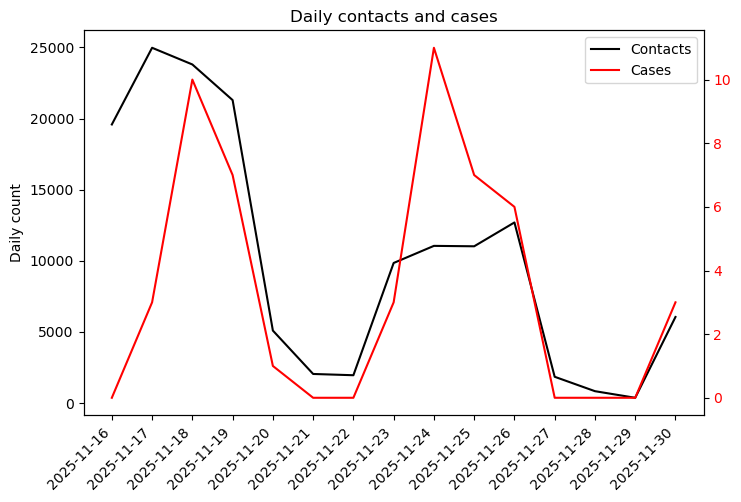

In [6]:
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(daily_counts['date'], daily_counts['contacts'], color='black', label='Contacts')
ax1.set_ylabel('Daily count', color='black')

ax2 = ax1.twinx()
ax2.plot(daily_counts['date'], daily_counts['infections'], color='red', label='Cases')
# ax2.set_ylabel('Case count', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Daily contacts and cases')
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
plt.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.savefig(path.join(output_folder, 'daily-contacts-cases.pdf'), bbox_inches='tight')
plt.show()

Now, we plot the daily counts of quarantine decisions

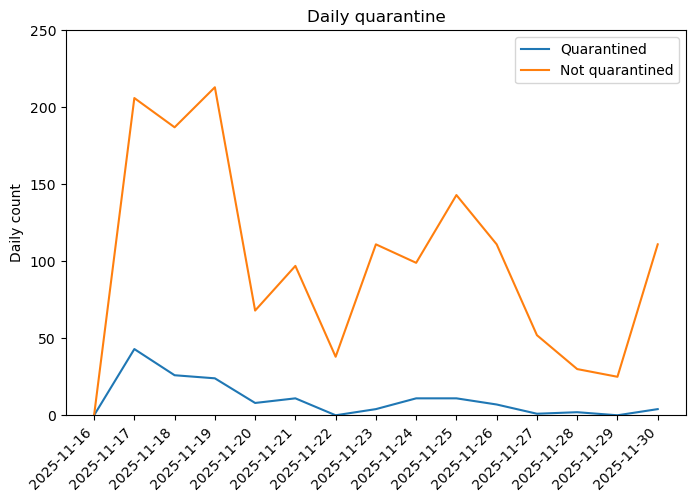

In [7]:
behaviors = ['quarantine_yes', 'quarantine_no']
labels = ['Quarantined', 'Not quarantined']
maxc = 250
plt.figure(figsize=(8, 5))
plt.title('Daily quarantine')

for b, t in zip(behaviors, labels):
    plt.plot(daily_counts['date'], daily_counts[b], label=t)

plt.xticks(rotation=45, ha='right')
plt.ylim(0, maxc)
plt.ylabel('Daily count')

plt.legend()
    
plt.savefig(path.join(output_folder, 'daily-quarantine.pdf'), bbox_inches='tight')
plt.show()

### Combined daily activity and quarantine figure

This manuscript figure combines daily Bluetooth contact records and simulated infections with daily quarantine choices. Panel A uses separate vertical scales because raw contact records and infections differ substantially in magnitude. Panel B shows response counts on one scale; both panels share the study-date axis.

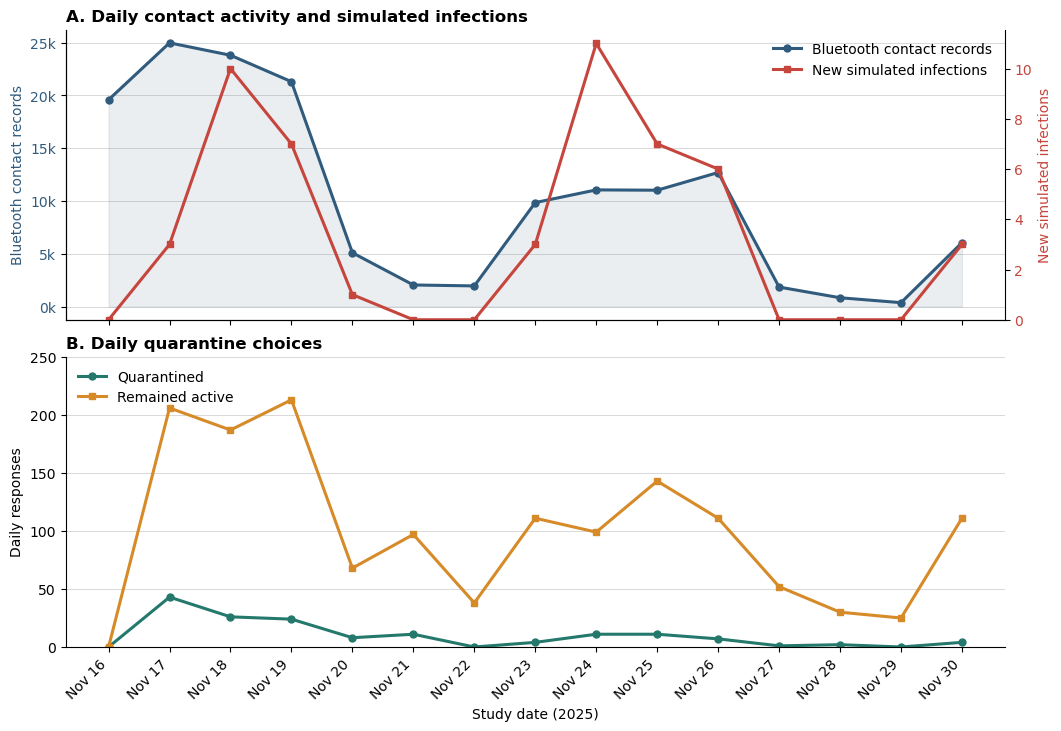

Saved: ./output/202/daily-activity-and-quarantine-two-panel.pdf
Saved: ./output/202/daily-activity-and-quarantine-two-panel.png


In [16]:
from matplotlib.dates import DateFormatter, DayLocator
from matplotlib.ticker import FuncFormatter

daily_plot = daily_counts.sort_values('date').copy()
daily_plot['date'] = pd.to_datetime(daily_plot['date'])

contact_color = '#315B7D'
infection_color = '#C6453D'
quarantine_color = '#24796C'
active_color = '#D68A28'

fig, axes = plt.subplots(
    2,
    1,
    figsize=(10.5, 7.2),
    sharex=True,
    constrained_layout=True,
 )

# Panel A: contact records and simulated infections require separate scales.
ax_contacts = axes[0]
contact_line = ax_contacts.plot(
    daily_plot['date'],
    daily_plot['contacts'],
    color=contact_color,
    linewidth=2.2,
    marker='o',
    markersize=5,
    label='Bluetooth contact records',
 )[0]
ax_contacts.fill_between(
    daily_plot['date'],
    daily_plot['contacts'],
    color=contact_color,
    alpha=0.10,
 )
ax_contacts.set_ylabel('Bluetooth contact records', color=contact_color)
ax_contacts.tick_params(axis='y', labelcolor=contact_color)
ax_contacts.yaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f'{value / 1000:.0f}k'),
 )

ax_infections = ax_contacts.twinx()
infection_line = ax_infections.plot(
    daily_plot['date'],
    daily_plot['infections'],
    color=infection_color,
    linewidth=2.2,
    marker='s',
    markersize=5,
    label='New simulated infections',
 )[0]
ax_infections.set_ylabel('New simulated infections', color=infection_color)
ax_infections.tick_params(axis='y', labelcolor=infection_color)
ax_infections.set_ylim(bottom=0)
ax_contacts.set_title(
    'A. Daily contact activity and simulated infections',
    loc='left',
    fontweight='bold',
 )
ax_contacts.legend(
    [contact_line, infection_line],
    [contact_line.get_label(), infection_line.get_label()],
    frameon=False,
    loc='upper right',
 )

# Panel B: observed daily quarantine-prompt responses.
ax_choices = axes[1]
ax_choices.plot(
    daily_plot['date'],
    daily_plot['quarantine_yes'],
    color=quarantine_color,
    linewidth=2.2,
    marker='o',
    markersize=5,
    label='Quarantined',
 )
ax_choices.plot(
    daily_plot['date'],
    daily_plot['quarantine_no'],
    color=active_color,
    linewidth=2.2,
    marker='s',
    markersize=5,
    label='Remained active',
 )
ax_choices.set(
    ylabel='Daily responses',
    xlabel='Study date (2025)',
    ylim=(0, 250),
 )
ax_choices.set_title(
    'B. Daily quarantine choices',
    loc='left',
    fontweight='bold',
 )
ax_choices.legend(frameon=False, loc='upper left')

for axis in axes:
    axis.grid(axis='y', color='#D8D8D8', linewidth=0.7)
    axis.set_axisbelow(True)
    axis.spines[['top', 'right']].set_visible(False)

ax_infections.spines['top'].set_visible(False)
axes[-1].xaxis.set_major_locator(DayLocator(interval=1))
axes[-1].xaxis.set_major_formatter(DateFormatter('%b %d'))
plt.setp(axes[-1].get_xticklabels(), rotation=45, ha='right')

daily_figure_base = path.join(
    output_folder,
    'daily-activity-and-quarantine-two-panel',
 )
fig.savefig(daily_figure_base + '.pdf', bbox_inches='tight')
fig.savefig(daily_figure_base + '.png', dpi=600, bbox_inches='tight')
plt.show()

print(f"Saved: {daily_figure_base + '.pdf'}")
print(f"Saved: {daily_figure_base + '.png'}")

### Overall and gender-stratified quarantine rates

Panel A compares the observed quarantine-decision rate between randomized groups. Panel B shows the same decision-weighted rate by gender within each group. Error bars are 95% participant-cluster bootstrap confidence intervals; the participant is resampled so repeated decisions from the same person remain together. The bars are descriptive, while model-based GEE estimates provide the primary inference.

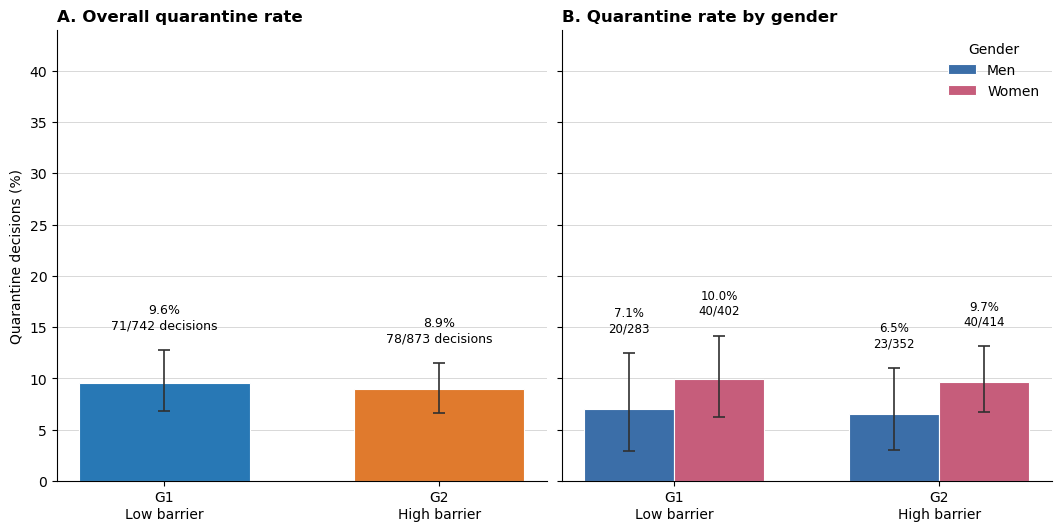

Overall rates:
 group  participants  quarantine  trials   rate  ci_low  ci_high
     1           188          71     742 0.0957  0.0684   0.1276
     2           215          78     873 0.0893  0.0663   0.1149

Gender-stratified rates:
 group  gender  participants  quarantine  trials   rate  ci_low  ci_high
     1     0.0            70          20     283 0.0707  0.0290   0.1250
     1     1.0            85          40     402 0.0995  0.0622   0.1416
     2     0.0            88          23     352 0.0653  0.0301   0.1102
     2     1.0            84          40     414 0.0966  0.0670   0.1313

Saved: ./output/202/quarantine-rate-overall-and-by-gender.pdf
Saved: ./output/202/quarantine-rate-overall-and-by-gender.png


In [9]:
def cluster_bootstrap_rate(frame, n_boot=5000, seed=12345):
    participant_data = frame[['quarantine', 'total_trials']].dropna()
    rng = np.random.default_rng(seed)
    sampled_indices = rng.integers(
        0,
        len(participant_data),
        size=(n_boot, len(participant_data)),
    )
    quarantine = participant_data['quarantine'].to_numpy()
    trials = participant_data['total_trials'].to_numpy()
    bootstrap_rates = (
        quarantine[sampled_indices].sum(axis=1)
        / trials[sampled_indices].sum(axis=1)
    )
    return np.percentile(bootstrap_rates, [2.5, 97.5])


def summarize_quarantine_rate(frame, strata, seed=12345):
    rows = []
    for index, (values, stratum) in enumerate(frame.groupby(strata, observed=True)):
        values = values if isinstance(values, tuple) else (values,)
        quarantine = int(stratum['quarantine'].sum())
        trials = int(stratum['total_trials'].sum())
        ci_low, ci_high = cluster_bootstrap_rate(
            stratum,
            seed=seed + index,
        )
        rows.append({
            **dict(zip(strata, values)),
            'participants': len(stratum),
            'quarantine': quarantine,
            'trials': trials,
            'rate': quarantine / trials,
            'ci_low': ci_low,
            'ci_high': ci_high,
        })
    return pd.DataFrame(rows)


overall_rates = summarize_quarantine_rate(users, ['group'])
gender_rates = summarize_quarantine_rate(
    users.dropna(subset=['gender']),
    ['group', 'gender'],
 )

group_labels = {1: 'G1\nLow barrier', 2: 'G2\nHigh barrier'}
gender_names = {0.0: 'Men', 1.0: 'Women'}
group_colors = {1: '#2878B5', 2: '#E07A2D'}
gender_colors = {0.0: '#3B6EA8', 1.0: '#C65D7B'}

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10.5, 5.2),
    sharey=True,
    constrained_layout=True,
 )

# Panel A: overall randomized-group contrast.
ax = axes[0]
overall_rates = overall_rates.sort_values('group')
overall_x = np.arange(len(overall_rates))
overall_bars = ax.bar(
    overall_x,
    overall_rates['rate'] * 100,
    width=0.62,
    color=[group_colors[group] for group in overall_rates['group']],
    edgecolor='white',
    linewidth=0.8,
    yerr=np.vstack([
        overall_rates['rate'] - overall_rates['ci_low'],
        overall_rates['ci_high'] - overall_rates['rate'],
    ]) * 100,
    capsize=4,
    error_kw={'elinewidth': 1.2, 'capthick': 1.2, 'ecolor': '#303030'},
 )

for bar, row in zip(overall_bars, overall_rates.itertuples()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        row.ci_high * 100 + 1.8,
        f'{row.rate:.1%}\n{row.quarantine}/{row.trials} decisions',
        ha='center',
        va='bottom',
        fontsize=9,
    )

ax.set_xticks(
    overall_x,
    [group_labels[group] for group in overall_rates['group']],
 )
ax.set_title('A. Overall quarantine rate', loc='left', fontweight='bold')
ax.set_ylabel('Quarantine decisions (%)')

# Panel B: two gender bars within each randomized group.
ax = axes[1]
groups = [1, 2]
genders = [0.0, 1.0]
group_x = np.arange(len(groups))
bar_width = 0.34

for gender_index, gender in enumerate(genders):
    subset = (
        gender_rates[gender_rates['gender'] == gender]
        .set_index('group')
        .loc[groups]
        .reset_index()
    )
    positions = group_x + (gender_index - 0.5) * bar_width
    bars = ax.bar(
        positions,
        subset['rate'] * 100,
        width=bar_width,
        color=gender_colors[gender],
        edgecolor='white',
        linewidth=0.8,
        yerr=np.vstack([
            subset['rate'] - subset['ci_low'],
            subset['ci_high'] - subset['rate'],
        ]) * 100,
        capsize=4,
        error_kw={'elinewidth': 1.2, 'capthick': 1.2, 'ecolor': '#303030'},
        label=gender_names[gender],
    )
    for bar, row in zip(bars, subset.itertuples()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            row.ci_high * 100 + 1.8,
            f'{row.rate:.1%}\n{row.quarantine}/{row.trials}',
            ha='center',
            va='bottom',
            fontsize=8.5,
        )

ax.set_xticks(group_x, [group_labels[group] for group in groups])
ax.set_title('B. Quarantine rate by gender', loc='left', fontweight='bold')
ax.legend(title='Gender', frameon=False, loc='upper right')

for ax in axes:
    ax.set_ylim(0, 44)
    ax.grid(axis='y', color='#D8D8D8', linewidth=0.7)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

figure_base = path.join(
    output_folder,
    'quarantine-rate-overall-and-by-gender',
 )
fig.savefig(figure_base + '.pdf', bbox_inches='tight')
fig.savefig(figure_base + '.png', dpi=600, bbox_inches='tight')
plt.show()

print('Overall rates:')
print(overall_rates.round(4).to_string(index=False))
print('\nGender-stratified rates:')
print(gender_rates.round(4).to_string(index=False))
print(f"\nSaved: {figure_base + '.pdf'}")
print(f"Saved: {figure_base + '.png'}")

### Histograms of survey responses

The three survey instruments are shown as separate panels, each containing a 2 × 2 grid for Questions 1–4. Bars show the percentage of valid responses so distributions remain comparable despite different survey completion counts. Gender is plotted separately.

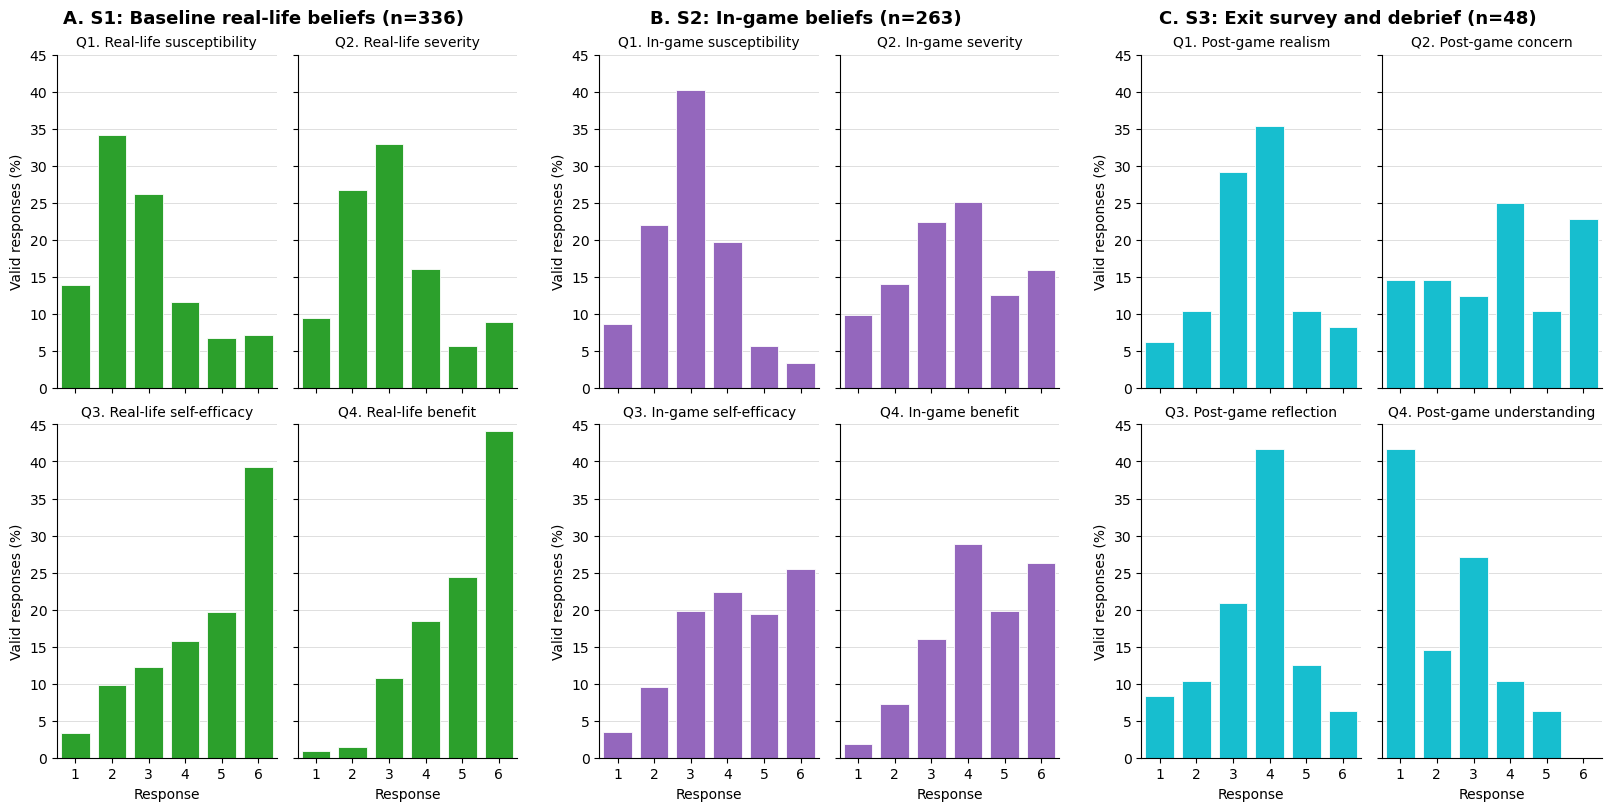

S1: valid n={'S1_Q1': 336, 'S1_Q2': 336, 'S1_Q3': 336, 'S1_Q4': 336}; percentage totals={'S1_Q1': 100.0, 'S1_Q2': 100.0, 'S1_Q3': 100.0, 'S1_Q4': 100.0}
S2: valid n={'S2_Q1': 263, 'S2_Q2': 263, 'S2_Q3': 263, 'S2_Q4': 263}; percentage totals={'S2_Q1': 100.0, 'S2_Q2': 100.0, 'S2_Q3': 100.0, 'S2_Q4': 100.0}
S3: valid n={'S3_Q1': 48, 'S3_Q2': 48, 'S3_Q3': 48, 'S3_Q4': 48}; percentage totals={'S3_Q1': 100.0, 'S3_Q2': 100.0, 'S3_Q3': 100.0, 'S3_Q4': 100.0}


In [10]:
survey_panels = {
    'S1': {'label': 'Baseline real-life beliefs', 'color': 'tab:green'},
    'S2': {'label': 'In-game beliefs', 'color': 'tab:purple'},
    'S3': {'label': 'Exit survey and debrief', 'color': 'tab:cyan'},
}
question_numbers = range(1, 5)
response_levels = np.arange(1, 7)

response_percentages = {}
for survey in survey_panels:
    for question in question_numbers:
        variable = f'{survey}_Q{question}'
        valid_responses = users[variable].dropna()
        response_percentages[variable] = (
            valid_responses.value_counts(normalize=True)
            .reindex(response_levels, fill_value=0)
            .mul(100)
        )

y_max = max(percentages.max() for percentages in response_percentages.values())
y_max = max(10, int(np.ceil(y_max / 5) * 5))

fig = plt.figure(figsize=(16, 8), constrained_layout=True)
subfigures = fig.subfigures(1, 3, wspace=0.05)

for panel_label, (survey, panel) in zip('ABC', survey_panels.items()):
    subfigure = subfigures[list(survey_panels).index(survey)]
    axes = subfigure.subplots(2, 2, sharex=True, sharey=True)
    survey_variables = [f'{survey}_Q{question}' for question in question_numbers]
    survey_n = int(users[survey_variables].notna().all(axis=1).sum())
    subfigure.suptitle(
        f'{panel_label}. {survey}: {panel["label"]} (n={survey_n})',
        fontsize=13,
        fontweight='bold',
    )

    for question, axis in zip(question_numbers, axes.flat):
        variable = f'{survey}_Q{question}'
        percentages = response_percentages[variable]
        axis.bar(
            response_levels,
            percentages,
            width=0.78,
            color=panel['color'],
            edgecolor='white',
            linewidth=0.6,
        )
        axis.set_title(f'Q{question}. {topic_map[variable]}', fontsize=10)
        axis.set_xticks(response_levels)
        axis.set_xlim(0.5, 6.5)
        axis.set_ylim(0, y_max)
        axis.grid(axis='y', color='#D9D9D9', linewidth=0.6)
        axis.set_axisbelow(True)
        axis.spines[['top', 'right']].set_visible(False)

    axes[1, 0].set_xlabel('Response')
    axes[1, 1].set_xlabel('Response')
    axes[0, 0].set_ylabel('Valid responses (%)')
    axes[1, 0].set_ylabel('Valid responses (%)')

output_stem = path.join(output_folder, 'S1-S2-S3-survey-response-histograms')
fig.savefig(output_stem + '.pdf', bbox_inches='tight')
fig.savefig(output_stem + '.png', dpi=600, bbox_inches='tight')
plt.show()

for survey in survey_panels:
    survey_variables = [f'{survey}_Q{question}' for question in question_numbers]
    valid_counts = users[survey_variables].notna().sum().astype(int).to_dict()
    percentage_totals = {
        variable: round(float(response_percentages[variable].sum()), 10)
        for variable in survey_variables
    }
    print(f'{survey}: valid n={valid_counts}; percentage totals={percentage_totals}')

## Marginal comparison between quarantine rate and belief variables

Real-life susceptibility-quarantine rate
N: 336
Pooled Spearman correlation: 0.0174
Pooled p-value: 0.7502

Group-specific Spearman correlations:
G1: N=159, rho=0.0005, p=0.9953
G2: N=177, rho=0.0341, p=0.6521

Level-specific summaries:
group  level  n  mean  ci_low  ci_high
   G1    1.0 20 0.073   0.014    0.154
   G1    2.0 56 0.119   0.062    0.185
   G1    3.0 39 0.166   0.073    0.278
   G1    4.0 21 0.122   0.008    0.265
   G1    5.0 13 0.074   0.000    0.163
   G1    6.0 10 0.101   0.000    0.252
   G2    1.0 27 0.092   0.022    0.189
   G2    2.0 59 0.103   0.055    0.161
   G2    3.0 49 0.108   0.049    0.181
   G2    4.0 18 0.160   0.044    0.305
   G2    5.0 10 0.014   0.000    0.043
   G2    6.0 14 0.157   0.034    0.319


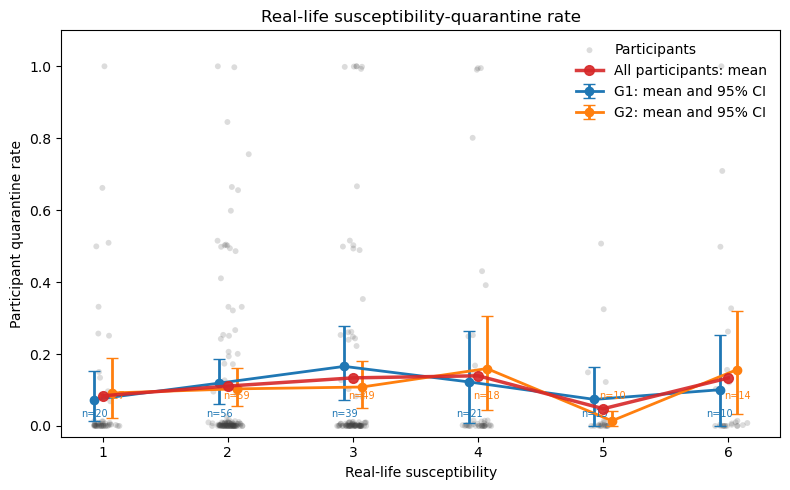

Real-life severity-quarantine rate
N: 336
Pooled Spearman correlation: 0.1320
Pooled p-value: 0.0155

Group-specific Spearman correlations:
G1: N=159, rho=0.1806, p=0.0227
G2: N=177, rho=0.0790, p=0.2961

Level-specific summaries:
group  level  n  mean  ci_low  ci_high
   G1    1.0 19 0.043   0.000    0.120
   G1    2.0 39 0.107   0.037    0.187
   G1    3.0 46 0.100   0.037    0.174
   G1    4.0 24 0.212   0.096    0.348
   G1    5.0 12 0.146   0.014    0.319
   G1    6.0 19 0.141   0.045    0.248
   G2    1.0 13 0.123   0.000    0.308
   G2    2.0 51 0.144   0.071    0.221
   G2    3.0 65 0.061   0.024    0.106
   G2    4.0 30 0.124   0.047    0.212
   G2    5.0  7 0.126   0.029    0.248
   G2    6.0 11 0.144   0.043    0.259


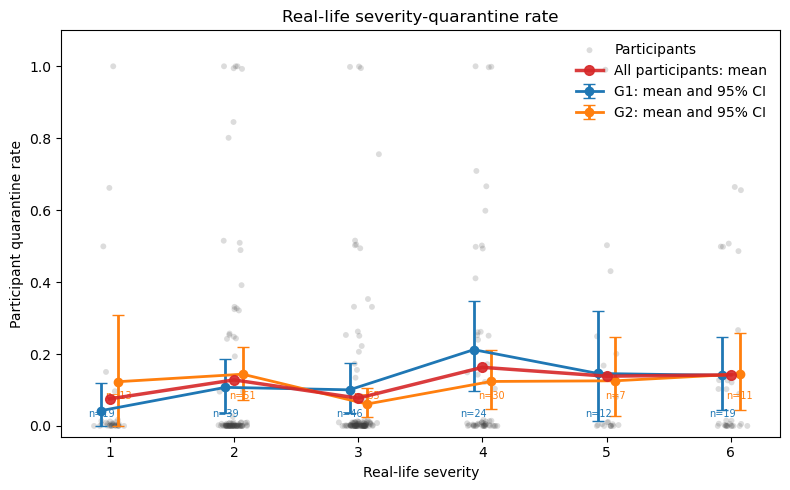

Real-life self-efficacy-quarantine rate
N: 336
Pooled Spearman correlation: -0.0663
Pooled p-value: 0.2258

Group-specific Spearman correlations:
G1: N=159, rho=-0.1113, p=0.1627
G2: N=177, rho=-0.0285, p=0.7064

Level-specific summaries:
group  level  n  mean  ci_low  ci_high
   G1    1.0  4 0.000   0.000    0.000
   G1    2.0 16 0.222   0.047    0.414
   G1    3.0 19 0.242   0.086    0.413
   G1    4.0 25 0.074   0.020    0.148
   G1    5.0 35 0.131   0.054    0.227
   G1    6.0 60 0.075   0.035    0.123
   G2    1.0  7 0.199   0.013    0.456
   G2    2.0 17 0.129   0.026    0.273
   G2    3.0 22 0.104   0.030    0.212
   G2    4.0 28 0.085   0.023    0.176
   G2    5.0 31 0.073   0.024    0.135
   G2    6.0 72 0.119   0.063    0.180


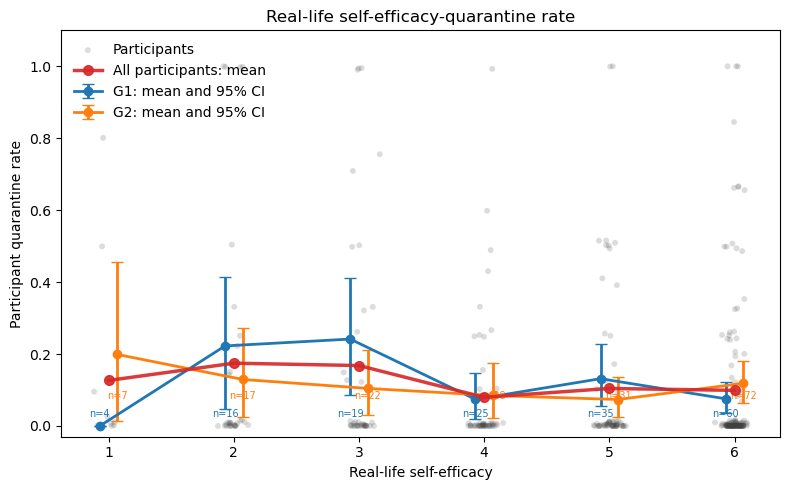

Real-life benefit-quarantine rate
N: 336
Pooled Spearman correlation: -0.0607
Pooled p-value: 0.2669

Group-specific Spearman correlations:
G1: N=159, rho=-0.0627, p=0.4321
G2: N=177, rho=-0.0601, p=0.4271

Level-specific summaries:
group  level  n  mean  ci_low  ci_high
   G1    2.0  1 0.000   0.000    0.000
   G1    3.0 20 0.228   0.075    0.408
   G1    4.0 23 0.074   0.018    0.143
   G1    5.0 43 0.121   0.053    0.203
   G1    6.0 72 0.106   0.053    0.166
   G2    1.0  3 0.000   0.000    0.000
   G2    2.0  4 0.083   0.000    0.250
   G2    3.0 16 0.186   0.070    0.336
   G2    4.0 39 0.081   0.030    0.147
   G2    5.0 39 0.172   0.081    0.278
   G2    6.0 76 0.078   0.042    0.121


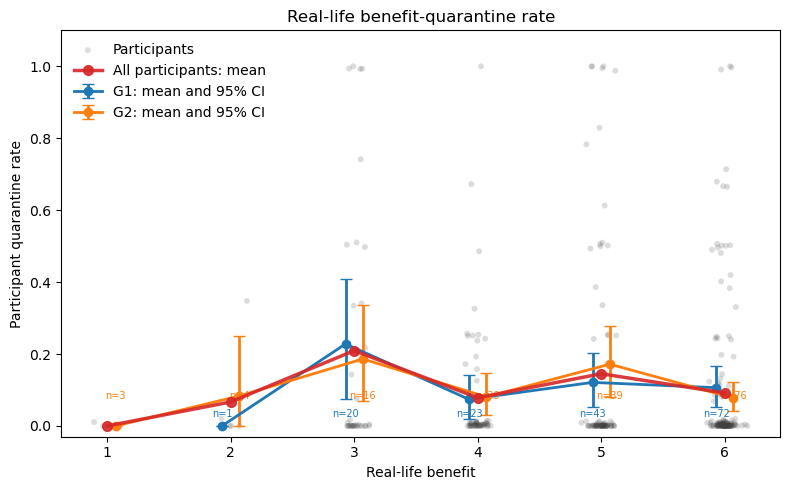

Gender-quarantine rate
N: 327
Pooled Spearman correlation: 0.1989
Pooled p-value: 0.0003

Group-specific Spearman correlations:
G1: N=155, rho=0.1708, p=0.0336
G2: N=172, rho=0.2261, p=0.0029

Level-specific summaries:
group  level  n  mean  ci_low  ci_high
   G1    0.0 70 0.090   0.036    0.152
   G1    1.0 85 0.144   0.090    0.207
   G2    0.0 88 0.070   0.034    0.113
   G2    1.0 84 0.146   0.092    0.210


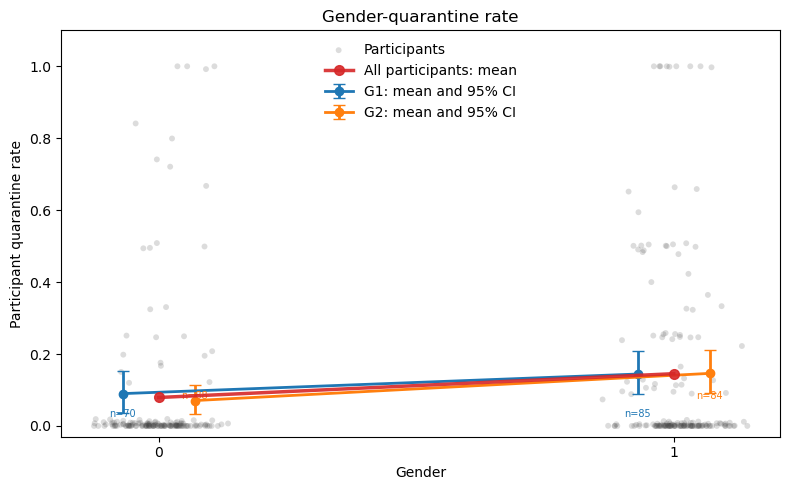

Affiliation-quarantine rate
N: 336
Pooled Spearman correlation: -0.0156
Pooled p-value: 0.7761

Group-specific Spearman correlations:
G1: N=159, rho=-0.1119, p=0.1603
G2: N=177, rho=0.0734, p=0.3314

Level-specific summaries:
group  level   n  mean  ci_low  ci_high
   G1    1.0 147 0.127   0.087    0.171
   G1    2.0   8 0.050   0.000    0.150
   G1    3.0   4 0.000   0.000    0.000
   G2    1.0 164 0.102   0.070    0.138
   G2    2.0   8 0.220   0.042    0.458
   G2    3.0   3 0.167   0.000    0.500
   G2    4.0   1 0.000   0.000    0.000
   G2    5.0   1 0.000   0.000    0.000


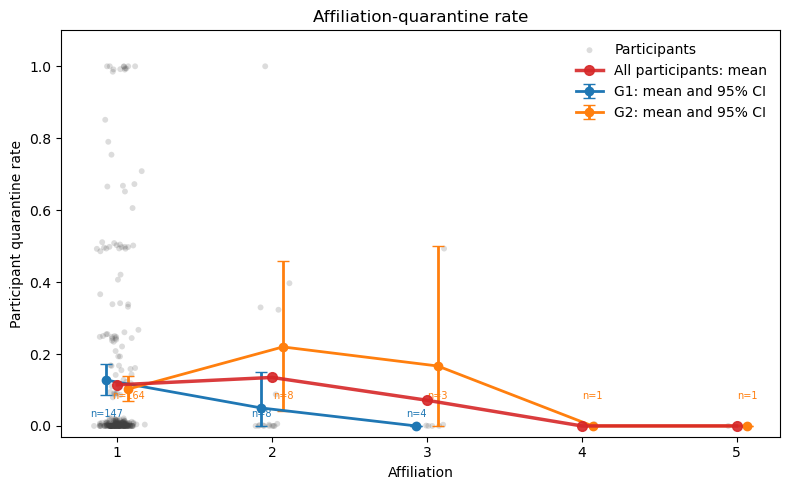

In-game susceptibility-quarantine rate
N: 263
Pooled Spearman correlation: 0.1489
Pooled p-value: 0.0157

Group-specific Spearman correlations:
G1: N=124, rho=0.0428, p=0.6366
G2: N=139, rho=0.2618, p=0.0018

Level-specific summaries:
group  level  n  mean  ci_low  ci_high
   G1    1.0 11 0.142   0.026    0.284
   G1    2.0 30 0.097   0.025    0.191
   G1    3.0 50 0.088   0.040    0.148
   G1    4.0 23 0.188   0.077    0.317
   G1    5.0  5 0.161   0.000    0.429
   G1    6.0  5 0.000   0.000    0.000
   G2    1.0 12 0.000   0.000    0.000
   G2    2.0 28 0.091   0.017    0.190
   G2    3.0 56 0.061   0.027    0.102
   G2    4.0 29 0.066   0.026    0.111
   G2    5.0 10 0.235   0.080    0.435
   G2    6.0  4 0.250   0.000    0.500


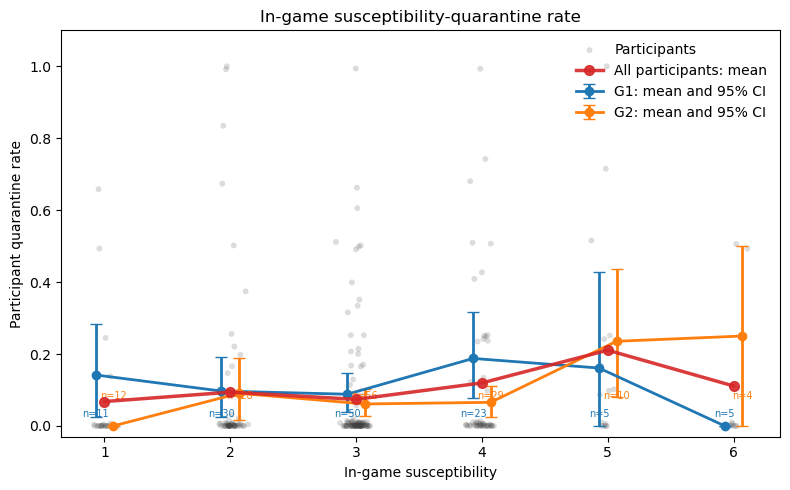

In-game severity-quarantine rate
N: 263
Pooled Spearman correlation: 0.0037
Pooled p-value: 0.9525

Group-specific Spearman correlations:
G1: N=124, rho=-0.1117, p=0.2169
G2: N=139, rho=0.0976, p=0.2528

Level-specific summaries:
group  level  n  mean  ci_low  ci_high
   G1    1.0  9 0.056   0.000    0.167
   G1    2.0 18 0.177   0.058    0.324
   G1    3.0 26 0.111   0.051    0.176
   G1    4.0 33 0.139   0.055    0.243
   G1    5.0 19 0.070   0.000    0.165
   G1    6.0 19 0.079   0.000    0.184
   G2    1.0 17 0.094   0.020    0.191
   G2    2.0 19 0.090   0.014    0.203
   G2    3.0 33 0.077   0.019    0.157
   G2    4.0 33 0.031   0.008    0.061
   G2    5.0 14 0.061   0.000    0.139
   G2    6.0 23 0.152   0.071    0.255


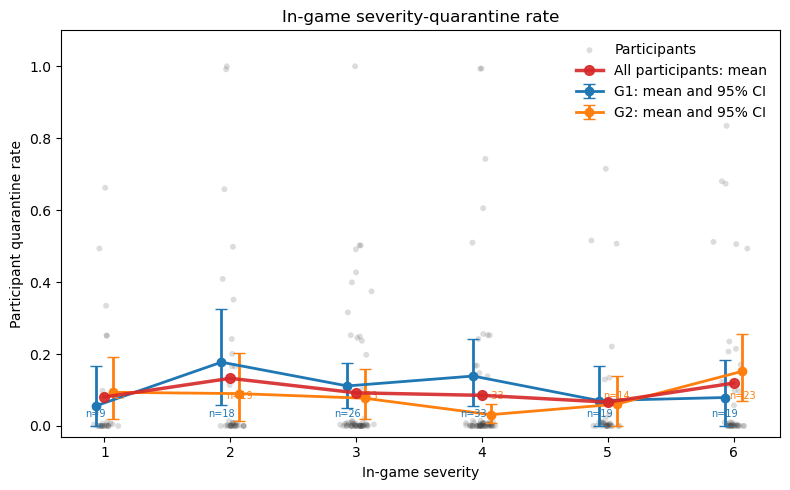

In-game self-efficacy-quarantine rate
N: 263
Pooled Spearman correlation: 0.0559
Pooled p-value: 0.3669

Group-specific Spearman correlations:
G1: N=124, rho=0.0164, p=0.8567
G2: N=139, rho=0.0923, p=0.2800

Level-specific summaries:
group  level  n  mean  ci_low  ci_high
   G1    1.0  3 0.056   0.000    0.167
   G1    2.0 16 0.065   0.000    0.148
   G1    3.0 20 0.082   0.000    0.178
   G1    4.0 23 0.188   0.081    0.313
   G1    5.0 30 0.127   0.047    0.223
   G1    6.0 32 0.095   0.024    0.188
   G2    1.0  6 0.000   0.000    0.000
   G2    2.0  9 0.165   0.025    0.387
   G2    3.0 32 0.043   0.003    0.094
   G2    4.0 36 0.067   0.026    0.124
   G2    5.0 21 0.194   0.092    0.317
   G2    6.0 35 0.054   0.020    0.100


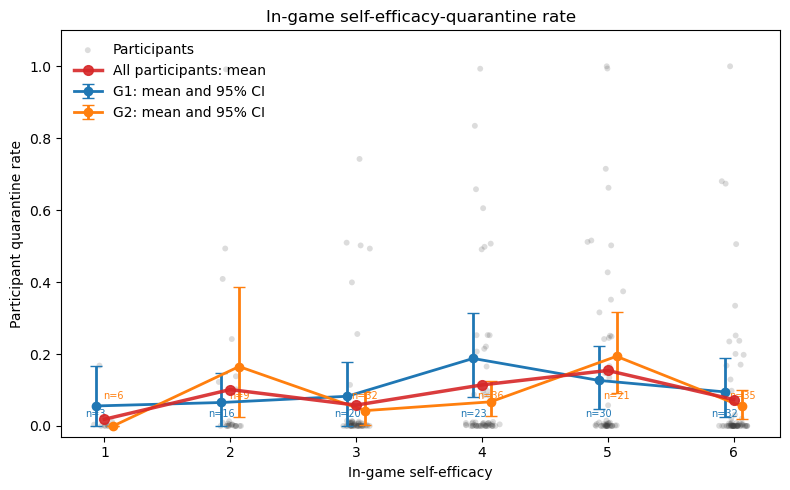

In-game benefit-quarantine rate
N: 263
Pooled Spearman correlation: 0.0750
Pooled p-value: 0.2256

Group-specific Spearman correlations:
G1: N=124, rho=-0.0481, p=0.5956
G2: N=139, rho=0.2032, p=0.0164

Level-specific summaries:
group  level  n  mean  ci_low  ci_high
   G1    1.0  3 0.222   0.000    0.500
   G1    2.0 11 0.140   0.036    0.268
   G1    3.0 21 0.142   0.043    0.267
   G1    4.0 31 0.054   0.005    0.122
   G1    5.0 24 0.167   0.058    0.301
   G1    6.0 34 0.092   0.034    0.163
   G2    1.0  2 0.000   0.000    0.000
   G2    2.0  8 0.074   0.000    0.199
   G2    3.0 21 0.071   0.000    0.190
   G2    4.0 45 0.050   0.023    0.081
   G2    5.0 28 0.104   0.028    0.206
   G2    6.0 35 0.114   0.057    0.180


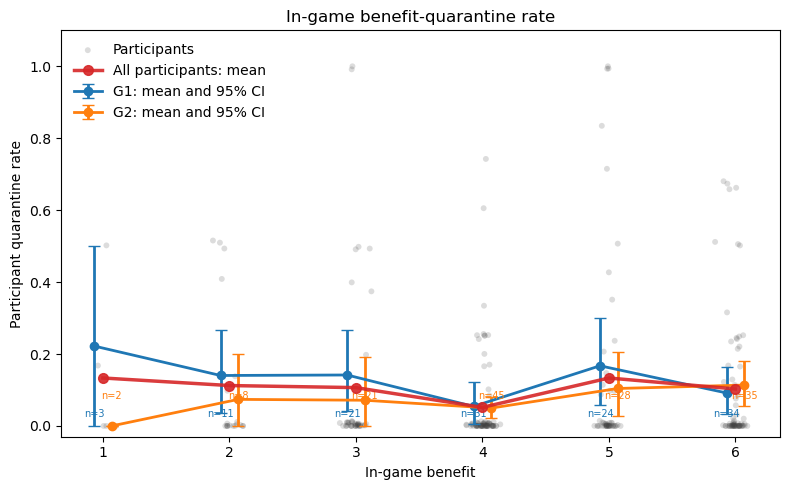

Post-game realism-quarantine rate
N: 48
Pooled Spearman correlation: 0.1526
Pooled p-value: 0.3004

Group-specific Spearman correlations:
G1: N=22, rho=0.0550, p=0.8080
G2: N=26, rho=0.2454, p=0.2269

Level-specific summaries:
group  level  n  mean  ci_low  ci_high
   G1    1.0  1 0.000   0.000    0.000
   G1    2.0  2 0.000   0.000    0.000
   G1    3.0  6 0.015   0.000    0.045
   G1    4.0  9 0.051   0.000    0.111
   G1    5.0  1 0.000   0.000    0.000
   G1    6.0  3 0.000   0.000    0.000
   G2    1.0  2 0.000   0.000    0.000
   G2    2.0  3 0.030   0.000    0.091
   G2    3.0  8 0.045   0.000    0.108
   G2    4.0  8 0.097   0.038    0.159
   G2    5.0  4 0.036   0.000    0.107
   G2    6.0  1 0.077   0.077    0.077


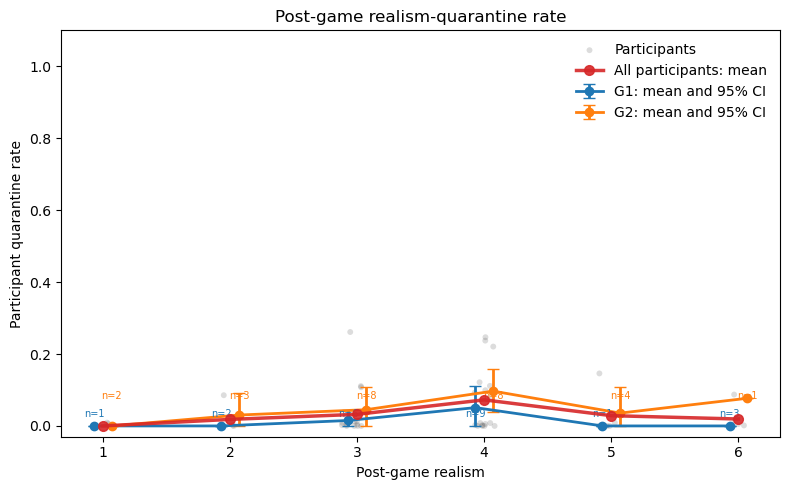

Post-game concern-quarantine rate
N: 48
Pooled Spearman correlation: 0.0194
Pooled p-value: 0.8959

Group-specific Spearman correlations:
G1: N=22, rho=-0.0104, p=0.9635
G2: N=26, rho=0.0382, p=0.8529

Level-specific summaries:
group  level  n  mean  ci_low  ci_high
   G1    1.0  4 0.000   0.000    0.000
   G1    2.0  2 0.125   0.000    0.250
   G1    3.0  4 0.023   0.000    0.068
   G1    4.0  5 0.017   0.000    0.050
   G1    6.0  7 0.018   0.000    0.054
   G2    1.0  3 0.000   0.000    0.000
   G2    2.0  5 0.090   0.018    0.172
   G2    3.0  2 0.111   0.000    0.222
   G2    4.0  7 0.050   0.000    0.121
   G2    5.0  5 0.047   0.000    0.104
   G2    6.0  4 0.047   0.000    0.094


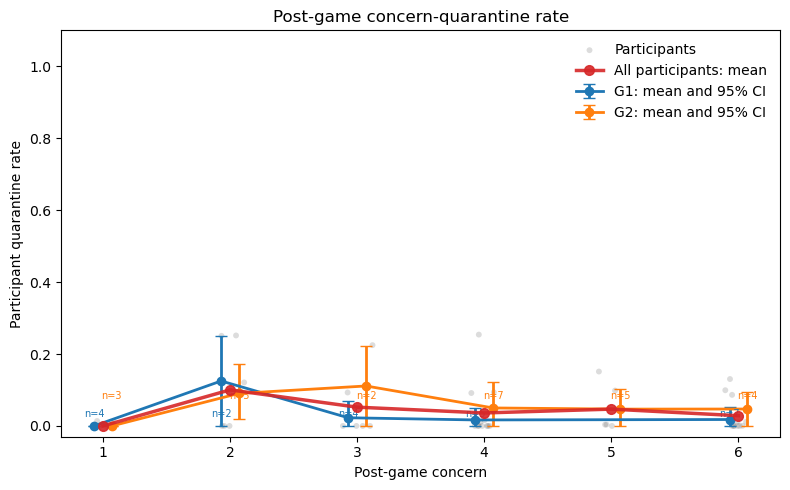

Post-game reflection-quarantine rate
N: 48
Pooled Spearman correlation: 0.0119
Pooled p-value: 0.9361

Group-specific Spearman correlations:
G1: N=22, rho=-0.2190, p=0.3275
G2: N=26, rho=0.1635, p=0.4249

Level-specific summaries:
group  level  n  mean  ci_low  ci_high
   G1    1.0  1 0.083   0.083    0.083
   G1    2.0  1 0.000   0.000    0.000
   G1    3.0  6 0.021   0.000    0.062
   G1    4.0 10 0.034   0.000    0.084
   G1    5.0  3 0.000   0.000    0.000
   G1    6.0  1 0.000   0.000    0.000
   G2    1.0  3 0.000   0.000    0.000
   G2    2.0  4 0.110   0.025    0.210
   G2    3.0  4 0.000   0.000    0.000
   G2    4.0 10 0.069   0.011    0.131
   G2    5.0  3 0.078   0.000    0.143
   G2    6.0  2 0.038   0.000    0.077


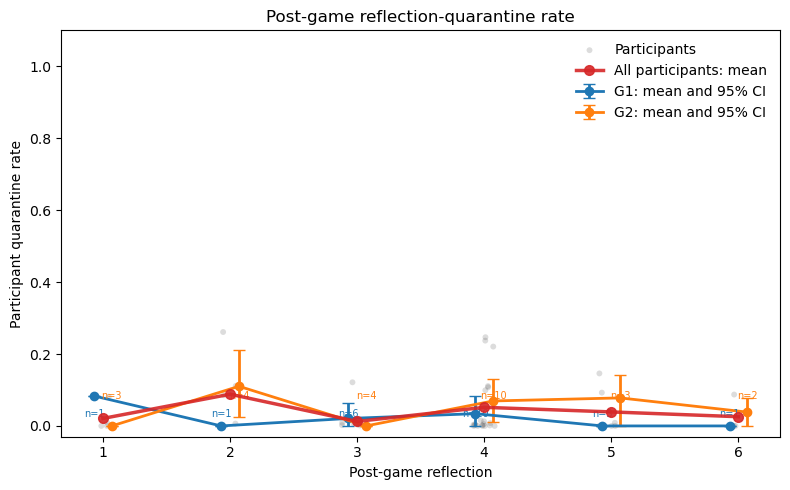

Post-game difficulty understanding-quarantine rate
N: 48
Pooled Spearman correlation: 0.2241
Pooled p-value: 0.1258

Group-specific Spearman correlations:
G1: N=22, rho=0.2922, p=0.1869
G2: N=26, rho=0.1332, p=0.5166

Level-specific summaries:
group  level  n  mean  ci_low  ci_high
   G1    1.0 11 0.008   0.000    0.025
   G1    2.0  2 0.000   0.000    0.000
   G1    3.0  5 0.042   0.000    0.092
   G1    4.0  2 0.000   0.000    0.000
   G1    5.0  2 0.125   0.000    0.250
   G2    1.0  9 0.064   0.000    0.130
   G2    2.0  5 0.040   0.000    0.085
   G2    3.0  8 0.024   0.000    0.052
   G2    4.0  3 0.114   0.000    0.250
   G2    5.0  1 0.143   0.143    0.143


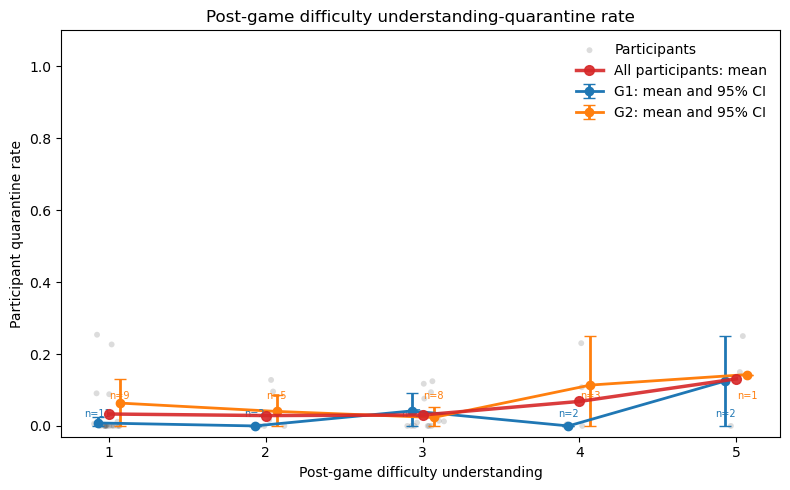

In [18]:
for var in topic_map.keys():
    title = topic_map.get(var, var) + '-quarantine rate'
    print(title)
    plot_marginal_relationship(
        users,
        var,
        title=title,
        separate_groups=True,
    )

### Combined belief--quarantine figure

This manuscript figure combines the four Health Belief Model domains while keeping real-life (S1) and in-game (S2) beliefs visually distinct. It presents pooled participant-level relationships because randomized-group moderation is tested in the GEE and quasi-binomial models. Gender is intentionally excluded: as a binary characteristic with a treatment interaction, it is better shown separately with arm-specific estimates in the gender results section.

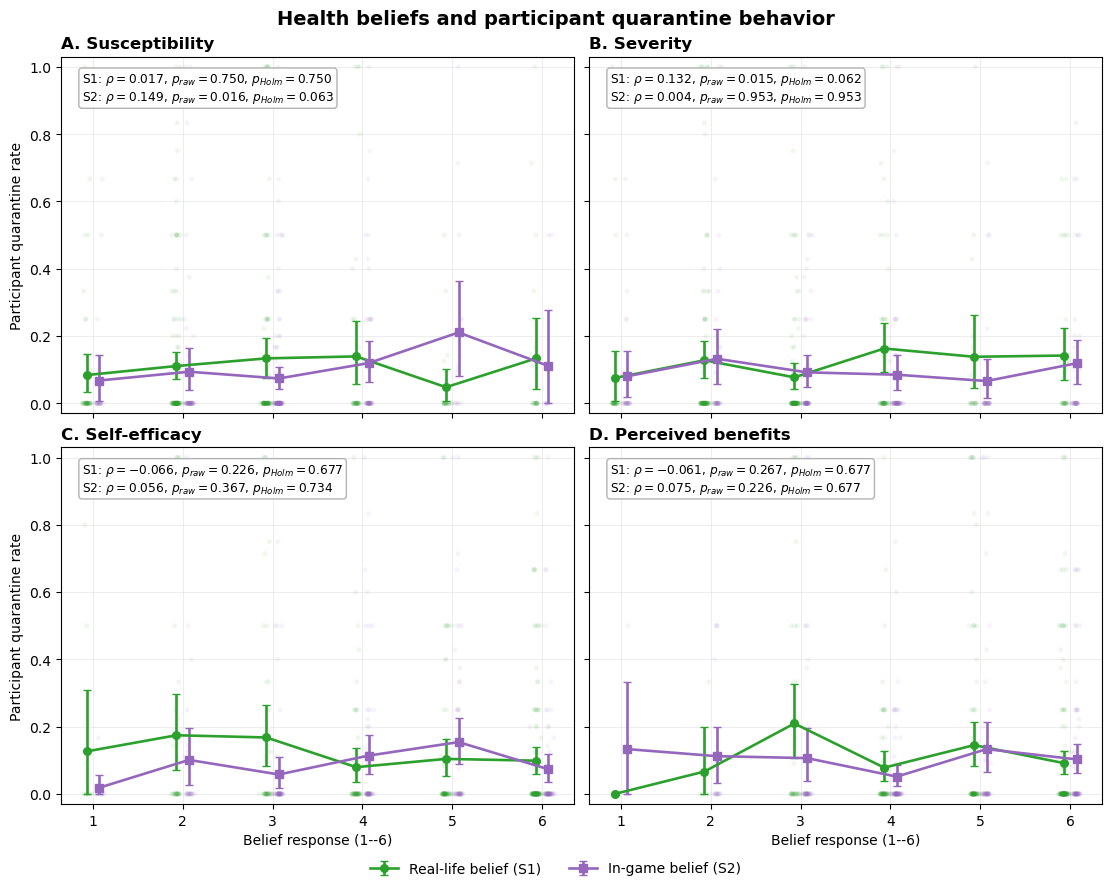

survey             domain   n     rho  p_raw  p_holm
    S1     Susceptibility 336  0.0174 0.7502  0.7502
    S1           Severity 336  0.1320 0.0155  0.0619
    S1      Self-efficacy 336 -0.0663 0.2258  0.6773
    S1 Perceived benefits 336 -0.0607 0.2669  0.6773
    S2     Susceptibility 263  0.1489 0.0157  0.0627
    S2           Severity 263  0.0037 0.9525  0.9525
    S2      Self-efficacy 263  0.0559 0.3669  0.7337
    S2 Perceived benefits 263  0.0750 0.2256  0.6769

Saved: ./output/202/S1-S2-beliefs-quarantine-rate-four-panel.pdf
Saved: ./output/202/S1-S2-beliefs-quarantine-rate-four-panel.png


In [12]:
from statsmodels.stats.multitest import multipletests

belief_behavior_domains = [
    ('Q1', 'Susceptibility'),
    ('Q2', 'Severity'),
    ('Q3', 'Self-efficacy'),
    ('Q4', 'Perceived benefits'),
]
survey_styles = {
    'S1': {
        'label': 'Real-life belief (S1)',
        'color': 'tab:green',
        'marker': 'o',
        'offset': -0.07,
    },
    'S2': {
        'label': 'In-game belief (S2)',
        'color': 'tab:purple',
        'marker': 's',
        'offset': 0.07,
    },
}

# Compute correlations first so Holm correction is applied within each survey.
association_rows = []
for survey in survey_styles:
    for question, domain in belief_behavior_domains:
        belief = f'{survey}_{question}'
        analysis_data = users[[belief, 'quarantine_rate']].dropna()
        correlation = stats.spearmanr(
            analysis_data[belief],
            analysis_data['quarantine_rate'],
        )
        association_rows.append({
            'survey': survey,
            'question': question,
            'domain': domain,
            'n': len(analysis_data),
            'rho': correlation.statistic,
            'p_raw': correlation.pvalue,
        })

belief_behavior_stats = pd.DataFrame(association_rows)
belief_behavior_stats['p_holm'] = np.nan
for survey in survey_styles:
    mask = belief_behavior_stats['survey'] == survey
    belief_behavior_stats.loc[mask, 'p_holm'] = multipletests(
        belief_behavior_stats.loc[mask, 'p_raw'],
        method='holm',
    )[1]

rng = np.random.default_rng(12345)
levels = np.arange(1, 7)
fig, axes = plt.subplots(
    2,
    2,
    figsize=(11, 8.8),
    sharex=True,
    sharey=True,
    constrained_layout=True,
 )

for panel_label, ax, (question, domain) in zip(
    'ABCD', axes.flat, belief_behavior_domains
):
    annotation_lines = []

    for survey, plot_style in survey_styles.items():
        belief = f'{survey}_{question}'
        analysis_data = users[[belief, 'quarantine_rate']].dropna()

        # Participant points are offset and jittered only for visualization.
        ax.scatter(
            analysis_data[belief]
            + plot_style['offset']
            + rng.normal(0, 0.025, len(analysis_data)),
            analysis_data['quarantine_rate'],
            s=13,
            alpha=0.075,
            color=plot_style['color'],
            edgecolors='none',
            rasterized=True,
        )

        summaries = []
        for level in levels:
            values = analysis_data.loc[
                analysis_data[belief] == level,
                'quarantine_rate',
            ].to_numpy()
            if len(values) == 0:
                continue

            bootstrap_means = np.array([
                rng.choice(values, size=len(values), replace=True).mean()
                for _ in range(2000)
            ])
            summaries.append({
                'level': level,
                'n': len(values),
                'mean': values.mean(),
                'ci_low': np.percentile(bootstrap_means, 2.5),
                'ci_high': np.percentile(bootstrap_means, 97.5),
            })

        summaries = pd.DataFrame(summaries)
        yerr = np.vstack([
            summaries['mean'] - summaries['ci_low'],
            summaries['ci_high'] - summaries['mean'],
        ])
        ax.errorbar(
            summaries['level'] + plot_style['offset'],
            summaries['mean'],
            yerr=yerr,
            fmt=plot_style['marker'] + '-',
            color=plot_style['color'],
            linewidth=1.9,
            markersize=5.5,
            capsize=3,
            zorder=4,
            label=plot_style['label'],
        )

        result = belief_behavior_stats.query(
            'survey == @survey and question == @question'
        ).iloc[0]
        annotation_lines.append(
            f"{survey}: $\\rho={result['rho']:.3f}$, "
            f"$p_{{raw}}={result['p_raw']:.3f}$, "
            f"$p_{{Holm}}={result['p_holm']:.3f}$"
        )

    ax.text(
        0.04,
        0.96,
        '\n'.join(annotation_lines),
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=8.8,
        zorder=10,
        bbox={
            'boxstyle': 'round,pad=0.25',
            'facecolor': 'white',
            'edgecolor': '#B0B0B0',
            'alpha': 0.96,
        },
    )
    ax.set_title(f'{panel_label}. {domain}', loc='left', fontweight='bold')
    ax.set(
        xlim=(0.65, 6.35),
        ylim=(-0.03, 1.03),
        xticks=levels,
    )
    ax.grid(color='#D8D8D8', linewidth=0.6, alpha=0.55)
    ax.set_axisbelow(True)

for ax in axes[-1, :]:
    ax.set_xlabel('Belief response (1--6)')
for ax in axes[:, 0]:
    ax.set_ylabel('Participant quarantine rate')

handles, legend_labels = axes.flat[0].get_legend_handles_labels()
fig.legend(
    handles,
    legend_labels,
    loc='outside lower center',
    ncol=2,
    frameon=False,
 )
fig.suptitle(
    'Health beliefs and participant quarantine behavior',
    fontsize=14,
    fontweight='bold',
 )

belief_quarantine_base = path.join(
    output_folder,
    'S1-S2-beliefs-quarantine-rate-four-panel',
 )
fig.savefig(belief_quarantine_base + '.pdf', bbox_inches='tight')
fig.savefig(belief_quarantine_base + '.png', dpi=600, bbox_inches='tight')
plt.show()

print(
    belief_behavior_stats[
        ['survey', 'domain', 'n', 'rho', 'p_raw', 'p_holm']
    ].round(4).to_string(index=False)
 )
print(f"\nSaved: {belief_quarantine_base + '.pdf'}")
print(f"Saved: {belief_quarantine_base + '.png'}")

### Post-game reflection and observed quarantine behavior

This exploratory figure focuses on S3-Q3, which asked how closely participants' game quarantine decisions reflected what they would do during a real-life outbreak. Because S3 was administered after gameplay, the figure describes retrospective behavioral correspondence rather than prospective prediction. Points are participant quarantine rates; lines show arm-specific means at each response level with 95% participant-bootstrap confidence intervals.

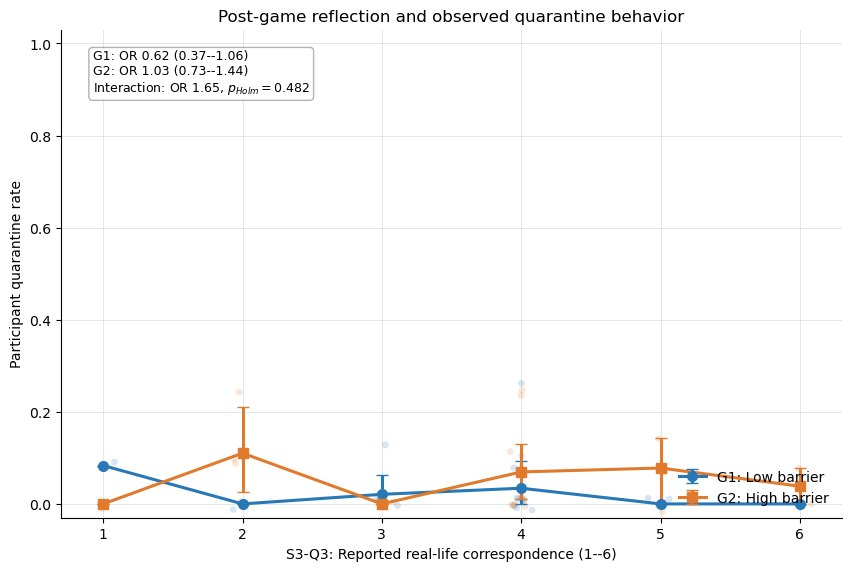

N participants: 48
Saved: ./output/202/S3-Q3-reflection-and-quarantine-by-group.pdf
Saved: ./output/202/S3-Q3-reflection-and-quarantine-by-group.png


In [13]:
s3_model_results = pd.read_csv(
    path.join(output_folder, 'S3-quarantine-exploratory-results.csv'),
 )
q3_result = s3_model_results.loc[
    s3_model_results['item'] == 'S3_Q3'
].iloc[0]

q3_data = users.dropna(subset=['S3_Q3', 'quarantine_rate', 'group']).copy()
q3_styles = {
    1: {'label': 'G1: Low barrier', 'color': '#2878B5', 'marker': 'o'},
    2: {'label': 'G2: High barrier', 'color': '#E07A2D', 'marker': 's'},
}
q3_levels = np.arange(1, 7)
rng = np.random.default_rng(21603)

fig, ax = plt.subplots(figsize=(8.4, 5.6), constrained_layout=True)

for group, plot_style in q3_styles.items():
    group_data = q3_data[q3_data['group'] == group]
    ax.scatter(
        group_data['S3_Q3'] + rng.normal(0, 0.055, len(group_data)),
        group_data['quarantine_rate']
        + rng.normal(0, 0.009, len(group_data)),
        s=24,
        alpha=0.18,
        color=plot_style['color'],
        edgecolors='none',
        rasterized=True,
    )

    summaries = []
    for level in q3_levels:
        values = group_data.loc[
            group_data['S3_Q3'] == level,
            'quarantine_rate',
        ].to_numpy()
        if len(values) == 0:
            continue
        bootstrap_means = np.array([
            rng.choice(values, size=len(values), replace=True).mean()
            for _ in range(5000)
        ])
        summaries.append({
            'level': level,
            'participants': len(values),
            'mean': values.mean(),
            'ci_low': np.percentile(bootstrap_means, 2.5),
            'ci_high': np.percentile(bootstrap_means, 97.5),
        })
    summaries = pd.DataFrame(summaries)
    yerr = np.vstack([
        summaries['mean'] - summaries['ci_low'],
        summaries['ci_high'] - summaries['mean'],
    ])
    ax.errorbar(
        summaries['level'],
        summaries['mean'],
        yerr=yerr,
        fmt=plot_style['marker'] + '-',
        color=plot_style['color'],
        linewidth=2.2,
        markersize=7,
        capsize=4,
        label=plot_style['label'],
        zorder=4,
    )

annotation = (
    f"G1: OR {q3_result['gee_g1_or']:.2f} "
    f"({q3_result['gee_g1_ci_low']:.2f}--{q3_result['gee_g1_ci_high']:.2f})\n"
    f"G2: OR {q3_result['gee_g2_or']:.2f} "
    f"({q3_result['gee_g2_ci_low']:.2f}--{q3_result['gee_g2_ci_high']:.2f})\n"
    f"Interaction: OR {q3_result['gee_interaction_or']:.2f}, "
    f"$p_{{Holm}}={q3_result['gee_interaction_p_holm']:.3f}$"
 )
ax.text(
    0.04,
    0.96,
    annotation,
    transform=ax.transAxes,
    ha='left',
    va='top',
    fontsize=9,
    bbox={
        'boxstyle': 'round,pad=0.3',
        'facecolor': 'white',
        'edgecolor': '#B0B0B0',
        'alpha': 0.96,
    },
 )

ax.set(
    xlabel='S3-Q3: Reported real-life correspondence (1--6)',
    ylabel='Participant quarantine rate',
    xlim=(0.7, 6.3),
    ylim=(-0.03, 1.03),
    xticks=q3_levels,
    title='Post-game reflection and observed quarantine behavior',
 )
ax.grid(color='#D8D8D8', linewidth=0.7, alpha=0.65)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False, loc='lower right')

q3_figure_base = path.join(
    output_folder,
    'S3-Q3-reflection-and-quarantine-by-group',
 )
fig.savefig(q3_figure_base + '.pdf', bbox_inches='tight')
fig.savefig(q3_figure_base + '.png', dpi=600, bbox_inches='tight')
plt.show()

print(f'N participants: {len(q3_data)}')
print(f"Saved: {q3_figure_base + '.pdf'}")
print(f"Saved: {q3_figure_base + '.png'}")

## Correlation between real-life and in-game beliefs

N paired responses: 257
Spearman correlation: rho=0.2038, p=0.001016
Kendall tau-b: tau=0.1728, p=0.0007555
Wilcoxon paired test: W=6181.0, p=0.02034
Median S2 - S1 difference: 0.00
Exact agreement: 31.9%
Within one scale point: 70.0%
Higher at S2: 41.2%
Lower at S2: 26.8%

Conditional S2 summaries:
 S1_level  n  mean_S2  median_S2  ci_low  ci_high
        1 35    2.571        3.0   2.114    3.029
        2 94    2.926        3.0   2.723    3.138
        3 63    3.143        3.0   2.936    3.365
        4 32    3.312        3.0   3.000    3.625
        5 14    2.929        3.0   2.286    3.571
        6 19    3.579        3.0   2.947    4.263


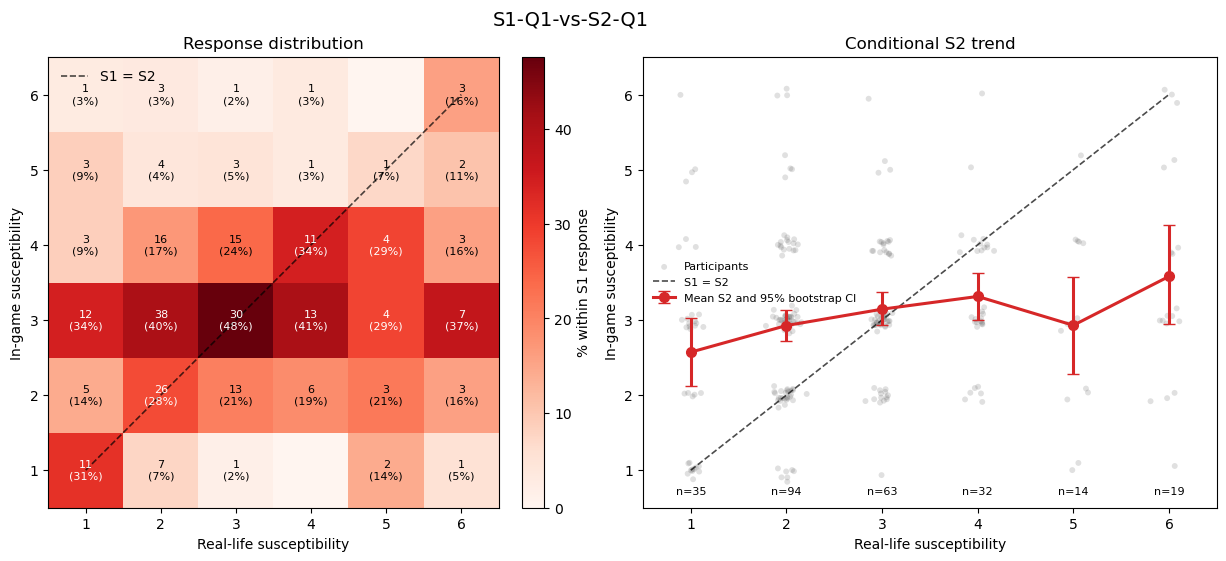

N paired responses: 257
Spearman correlation: rho=0.1263, p=0.04309
Kendall tau-b: tau=0.1026, p=0.04029
Wilcoxon paired test: W=6380.0, p=1.925e-05
Median S2 - S1 difference: 0.00
Exact agreement: 23.3%
Within one scale point: 58.4%
Higher at S2: 48.6%
Lower at S2: 28.0%

Conditional S2 summaries:
 S1_level  n  mean_S2  median_S2  ci_low  ci_high
        1 21    3.238        3.0   2.429    4.048
        2 66    3.318        3.0   2.970    3.667
        3 90    3.867        4.0   3.567    4.144
        4 43    3.465        3.0   3.070    3.860
        5 15    3.667        3.0   3.067    4.268
        6 22    4.182        5.0   3.455    4.864


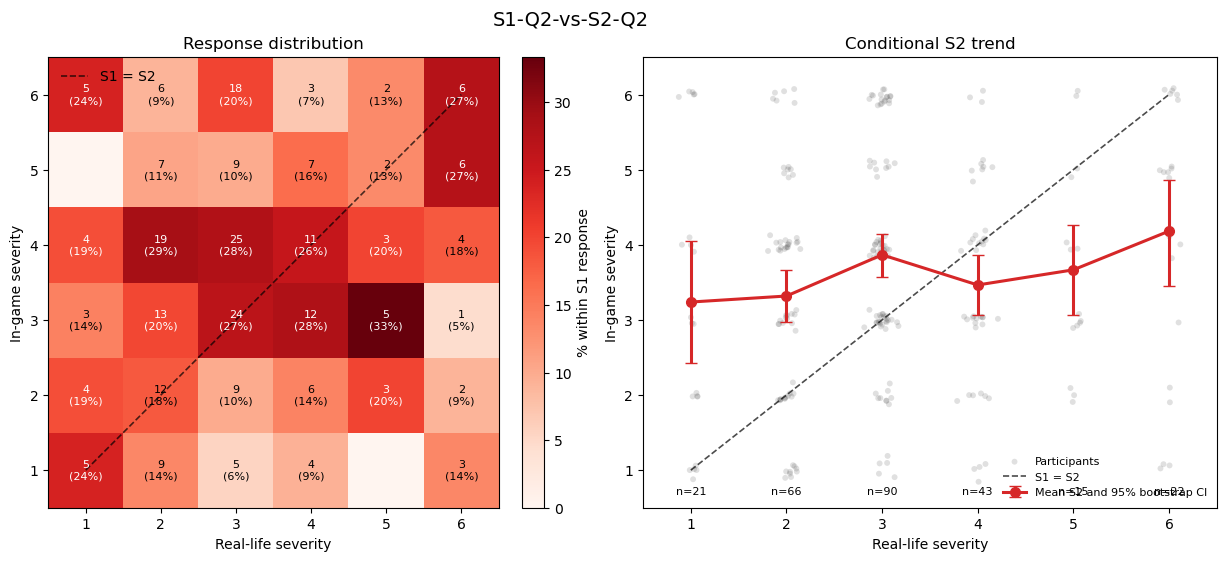

N paired responses: 257
Spearman correlation: rho=0.2674, p=1.389e-05
Kendall tau-b: tau=0.2214, p=1.2e-05
Wilcoxon paired test: W=4654.0, p=5.759e-05
Median S2 - S1 difference: 0.00
Exact agreement: 34.2%
Within one scale point: 61.9%
Higher at S2: 23.0%
Lower at S2: 42.8%

Conditional S2 summaries:
 S1_level   n  mean_S2  median_S2  ci_low  ci_high
        1   6    3.500        3.5   2.167    4.833
        2  23    3.565        3.0   3.000    4.130
        3  29    3.862        4.0   3.379    4.345
        4  46    4.130        4.0   3.717    4.522
        5  50    3.800        4.0   3.460    4.120
        6 103    4.660        5.0   4.379    4.932


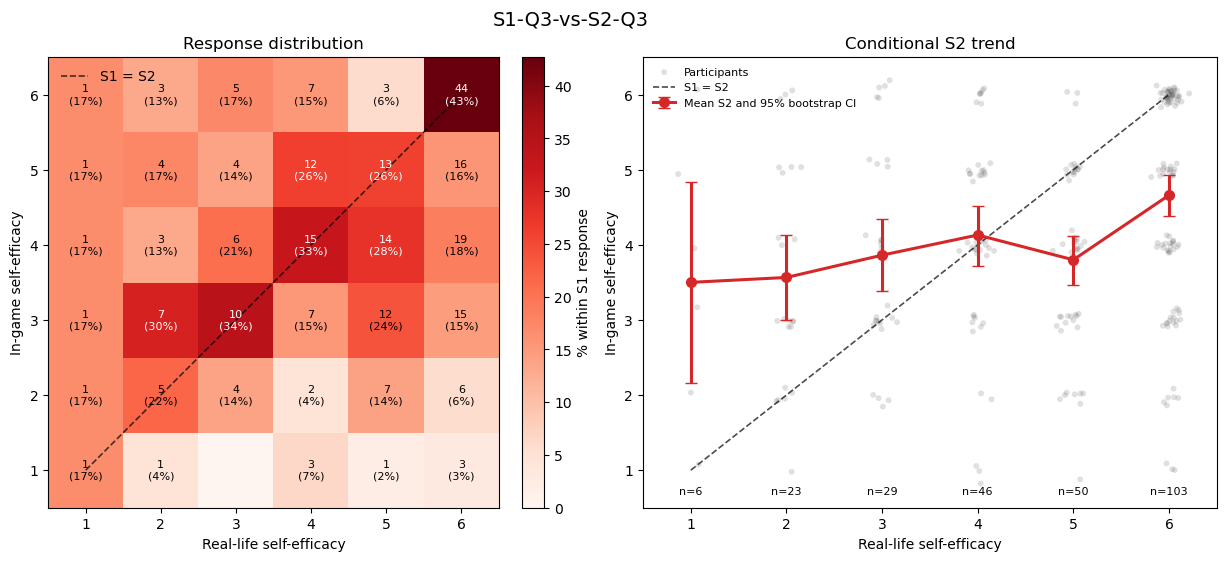

N paired responses: 257
Spearman correlation: rho=0.3531, p=5.798e-09
Kendall tau-b: tau=0.2988, p=8.97e-09
Wilcoxon paired test: W=2879.5, p=2.364e-11
Median S2 - S1 difference: 0.00
Exact agreement: 35.4%
Within one scale point: 70.0%
Higher at S2: 16.0%
Lower at S2: 48.6%

Conditional S2 summaries:
 S1_level   n  mean_S2  median_S2  ci_low  ci_high
        1   1    3.000        3.0   3.000    3.000
        2   2    4.500        4.5   3.000    6.000
        3  27    3.741        4.0   3.296    4.185
        4  51    3.804        4.0   3.451    4.118
        5  65    4.200        4.0   3.892    4.508
        6 111    4.829        5.0   4.604    5.054


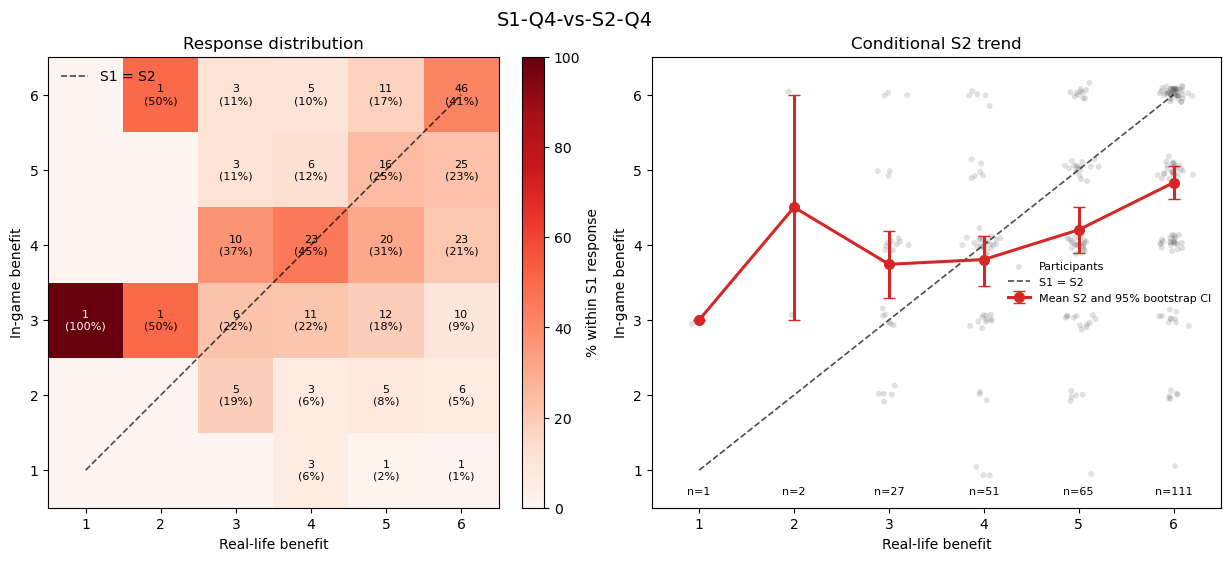

In [14]:
for question in range(1, 5):
    plot_belief_relationship(
        users,
        f'S1_Q{question}',
        f'S2_Q{question}',
        title=f'S1-Q{question}-vs-S2-Q{question}',
    )

### Combined four-domain figure

For the manuscript, the four matched belief relationships are combined natively from the paired data rather than rasterizing the individual PDFs. Each panel shows jittered participant responses, the conditional mean in-game response with a 95% bootstrap confidence interval, the identity line, and the Spearman rank correlation. The cell exports an editable vector PDF and a high-resolution PNG.

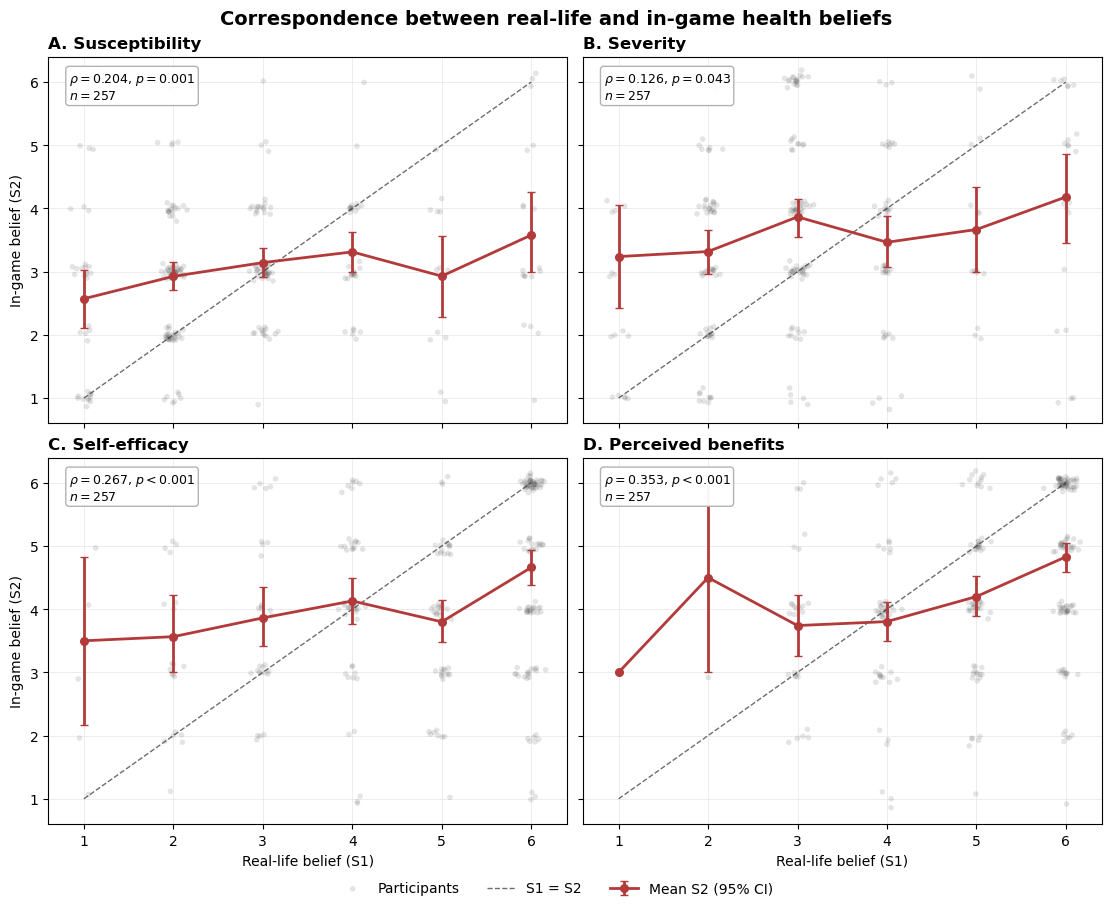

Saved: ./output/202/S1-S2-belief-correspondence-four-panel.pdf
Saved: ./output/202/S1-S2-belief-correspondence-four-panel.png


In [15]:
from string import ascii_uppercase

belief_domains = [
    ('S1_Q1', 'S2_Q1', 'Susceptibility'),
    ('S1_Q2', 'S2_Q2', 'Severity'),
    ('S1_Q3', 'S2_Q3', 'Self-efficacy'),
    ('S1_Q4', 'S2_Q4', 'Perceived benefits'),
]

rng = np.random.default_rng(12345)
levels = np.arange(1, 7)
fig, axes = plt.subplots(
    2,
    2,
    figsize=(11, 9),
    sharex=True,
    sharey=True,
    constrained_layout=True,
 )

for panel_label, ax, (s1_var, s2_var, domain) in zip(
    ascii_uppercase, axes.flat, belief_domains
):
    paired = users[[s1_var, s2_var]].dropna()
    s1 = paired[s1_var].to_numpy()
    s2 = paired[s2_var].to_numpy()

    # Jitter is visual only; all summaries use the original ordinal values.
    ax.scatter(
        s1 + rng.normal(0, 0.065, len(paired)),
        s2 + rng.normal(0, 0.065, len(paired)),
        s=16,
        alpha=0.14,
        color='#404040',
        edgecolors='none',
        rasterized=True,
        label='Participants',
    )

    summaries = []
    for level in levels:
        values = s2[s1 == level]
        if len(values) == 0:
            continue

        bootstrap_means = np.array([
            rng.choice(values, size=len(values), replace=True).mean()
            for _ in range(2000)
        ])
        summaries.append({
            'level': level,
            'n': len(values),
            'mean': values.mean(),
            'ci_low': np.percentile(bootstrap_means, 2.5),
            'ci_high': np.percentile(bootstrap_means, 97.5),
        })

    summaries = pd.DataFrame(summaries)
    yerr = np.vstack([
        summaries['mean'] - summaries['ci_low'],
        summaries['ci_high'] - summaries['mean'],
    ])
    ax.errorbar(
        summaries['level'],
        summaries['mean'],
        yerr=yerr,
        fmt='o-',
        color='#B33A3A',
        linewidth=2.0,
        markersize=5.5,
        capsize=3,
        zorder=4,
        label='Mean S2 (95% CI)',
    )
    ax.plot(
        levels,
        levels,
        linestyle='--',
        color='#1F1F1F',
        linewidth=1.0,
        alpha=0.65,
        label='S1 = S2',
    )

    spearman = stats.spearmanr(s1, s2)
    p_text = '$p<0.001$' if spearman.pvalue < 0.001 else f'$p={spearman.pvalue:.3f}$'
    ax.text(
        0.04,
        0.96,
        f'$\\rho={spearman.statistic:.3f}$, {p_text}\n$n={len(paired)}$',
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=9,
        zorder=10,
        bbox={
            'boxstyle': 'round,pad=0.25',
            'facecolor': 'white',
            'edgecolor': '#B0B0B0',
            'alpha': 0.96,
        },
    )
    ax.set_title(f'{panel_label}. {domain}', loc='left', fontweight='bold')
    ax.set(
        xlim=(0.6, 6.4),
        ylim=(0.6, 6.4),
        xticks=levels,
        yticks=levels,
    )
    ax.grid(color='#D8D8D8', linewidth=0.6, alpha=0.55)
    ax.set_axisbelow(True)

for ax in axes[-1, :]:
    ax.set_xlabel('Real-life belief (S1)')
for ax in axes[:, 0]:
    ax.set_ylabel('In-game belief (S2)')

handles, legend_labels = axes.flat[0].get_legend_handles_labels()
fig.legend(
    handles,
    legend_labels,
    loc='outside lower center',
    ncol=3,
    frameon=False,
 )
fig.suptitle(
    'Correspondence between real-life and in-game health beliefs',
    fontsize=14,
    fontweight='bold',
 )

combined_figure_base = path.join(output_folder, 'S1-S2-belief-correspondence-four-panel')
fig.savefig(combined_figure_base + '.pdf', bbox_inches='tight')
fig.savefig(combined_figure_base + '.png', dpi=600, bbox_inches='tight')
plt.show()

print(f"Saved: {combined_figure_base + '.pdf'}")
print(f"Saved: {combined_figure_base + '.png'}")